# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/An3DCu/ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup — the same slice, the same rule, the same forest

Nothing about the data or the models is re-chosen this week. The playbook is a *presentation* of
work that is already frozen: w03's contract, w04's rule and its reason codes, w05's forest, w06's
time-forward audit. So section 0 rebuilds all of it from the warehouse and checks nine numbers
against the committed receipts before a single recommendation is written.

Two things *are* new, and both are policy rather than modelling: the **gates** that decide which
pages may take an action slot at all, and the **thresholds** that decide when the queue should stop
being trusted. Both are declared as constants below, before anything is measured with them.

**June 2026 stays sealed.** w06 closed it for the capstone and this notebook does not open it. The
monitoring thresholds in section 4 are written down here precisely so the capstone can run them
once, on a month neither the rule nor the forest has ever seen.

In [1]:
import importlib.util, subprocess, sys

for pkg in ("duckdb", "huggingface_hub"):
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import json, os, pathlib, warnings
import duckdb, numpy as np, pandas as pd, sklearn
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 190)
SEED = 42          # same seed as w03, w04, w05 and w06 — same split, same numbers on a rerun

print(f"python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__} | "
      f"scikit-learn {sklearn.__version__} | duckdb {duckdb.__version__} | "
      f"matplotlib {matplotlib.__version__}")


def load_hf_token():
    if os.environ.get("HF_TOKEN"):
        return os.environ["HF_TOKEN"], "environment variable"
    for parent in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        env_file = parent / ".env"
        if env_file.exists():
            for line in env_file.read_text(encoding="utf-8").splitlines():
                if line.strip().startswith("HF_TOKEN="):
                    return line.split("=", 1)[1].strip().strip("\"'"), "local .env (gitignored)"
    try:
        from google.colab import userdata
        return userdata.get("HF_TOKEN"), "Colab Secret"
    except Exception:
        pass
    raise RuntimeError("No HF_TOKEN found. Set a Colab Secret named HF_TOKEN (read token).")


HF_TOKEN, token_source = load_hf_token()
print(f"HF read token loaded from: {token_source}")

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
DIM_CLIENTS = f"read_parquet('{REL}/dim_clients.parquet')"
DIM_CONTENT = f"read_parquet('{REL}/dim_content.parquet')"


def hf_sql(query, tries=6, base_wait=20):
    import time
    for attempt in range(tries):
        try:
            return con.sql(query).df()
        except Exception as exc:
            if "429" not in str(exc) or attempt == tries - 1:
                raise
            wait = base_wait * (attempt + 1)
            print(f"  hub returned HTTP 429, waiting {wait}s, retry {attempt + 1}/{tries - 1}")
            time.sleep(wait)


def fact(month):
    """One month partition of fact_content_daily_performance."""
    return f"read_parquet('{REL}/fact_content_daily_performance/month={month}/*.parquet')"


# --- lane constants: copied unchanged from w03 / w04 / w05 / w06 -------------------------------
FEATURE_MONTH = "2026-03"          # the queue this notebook ships is scored here
LABEL_MONTH   = "2026-04"          # strictly after the decision moment
DECISION_DATE = "2026-03-31"       # the moment the editor scores the queue
MIN_HISTORY   = "2026-01-01"       # client must have GSC history starting on/before this
MIN_IMP       = 100                # a page needs measurable search demand in the feature month
DECLINE_DROP  = 0.20               # "declining" = next month's impressions >20% below this month's
TOP_K         = 50                 # editorial capacity: the queue is 50 pages long

CONTRACT_FEATURES = ["log_imp_mar", "active_days", "pos_mar", "ctr_mar", "momentum_in_month"]
FEATURES = CONTRACT_FEATURES       # nothing is added this week either

MONTHS = ["2026-01", "2026-02", "2026-03", "2026-04", "2026-05"]
SEALED_MONTH = "2026-06"           # still sealed: the capstone opens it once, and only once
MID = {"2026-01": "2026-01-17", "2026-02": "2026-02-15", "2026-03": "2026-03-17",
       "2026-04": "2026-04-16", "2026-05": "2026-05-17"}
DAYS_IN_MONTH = {"2026-01": 31, "2026-02": 28, "2026-03": 31, "2026-04": 30, "2026-05": 31}
PAIRS = [("2026-01", "2026-02"), ("2026-02", "2026-03"),
         ("2026-03", "2026-04"), ("2026-04", "2026-05")]

# --- the playbook's own constants: every one of them is a policy choice, declared here ---------
# Section 1 measures two configurations of the same two queues and section 4 re-derives the choice
# from a pre-registered fallback rule. These are the shipped settings; the alternative is measured
# beside them rather than assumed away.
RULE_SLOTS    = TOP_K  # the editor's whole review budget goes to the frozen rule
TRIAL_SHADOW  = 10     # the model's queue rides along as SHADOW items: measured, never an editor slot
ALT_SPLIT     = (40, 10)   # the in-budget alternative section 1b prices: 40 rule slots + 10 trial slots
RISER_GATE    = 1.20   # w04 s1c: pages at/above this declined BELOW the base rate — never actioned
SPIKE_GATE    = 0.25   # w04 s3: one day holding >=25% of the month is a measurement suspicion
COVERAGE_GATE = 25     # live on fewer than 25 of the month's days: partial coverage fakes a slide
assert sum(ALT_SPLIT) == TOP_K, "the in-budget alternative must still fit the editor's capacity"

receipts = {"lane": "bleed_tracker", "seed": SEED, "top_k": TOP_K,
            "sklearn_version": sklearn.__version__, "contract_features": CONTRACT_FEATURES,
            "months_opened": MONTHS, "sealed_month": SEALED_MONTH,
            "rule_slots": RULE_SLOTS, "trial_shadow_items": TRIAL_SHADOW,
            "in_budget_alternative": {"rule_slots": ALT_SPLIT[0], "trial_slots": ALT_SPLIT[1]},
            "gates": {"riser": RISER_GATE, "spike_share": SPIKE_GATE, "min_active_days": COVERAGE_GATE,
                      "min_impressions_upstream": MIN_IMP}}


def precision_at_k_fair(df, score_col, label_col="label_declining", k=TOP_K):
    """w05's tie-fair metric, unchanged: ties are not allowed to choose the queue."""
    s = df[score_col].to_numpy()
    y = df[label_col].to_numpy()
    cut = np.sort(s)[::-1][k - 1]
    above, tied = s > cut, s == cut
    slots = k - int(above.sum())
    return float((y[above].sum() + slots * y[tied].mean()) / k)


def p50(df, score_col):
    """Shorthand: the tie-fair precision@50 this lane ships."""
    return precision_at_k_fair(df, score_col)


out_dir = pathlib.Path("../outputs")
fig_dir = pathlib.Path("../figures")
out_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

prev = {w: json.loads((out_dir / f"{w}_receipts.json").read_text(encoding="utf-8"))
        for w in ["w03_data_contract", "w04_baseline_score", "w05_model", "w06_validation_audit"]}
print(f"\nreceipts loaded from earlier weeks: {', '.join(prev)}")
print(f"the playbook ships {RULE_SLOTS} editor slots (frozen rule) + {TRIAL_SHADOW} shadow items (model)")
print(f"months this notebook may open: {', '.join(MONTHS)} | still sealed: {SEALED_MONTH}")

python 3.12.6 | numpy 1.26.4 | pandas 2.3.3 | scikit-learn 1.9.0 | duckdb 1.5.4 | matplotlib 3.10.9
HF read token loaded from: local .env (gitignored)

receipts loaded from earlier weeks: w03_data_contract, w04_baseline_score, w05_model, w06_validation_audit
the playbook ships 50 editor slots (frozen rule) + 10 shadow items (model)
months this notebook may open: 2026-01, 2026-02, 2026-03, 2026-04, 2026-05 | still sealed: 2026-06


### 0b. Five months of the same slice

One query per month, identical in shape to w03's and w06's: page-level GSC aggregates for every day
the warehouse reports as available, one row per client × content × month, ordered by
`content_hash_id` so a parallel `GROUP BY` cannot hand back a different row order on every rerun.

The population rules (100+ impressions, client history from before 2026-01-01) apply to the
**feature** month only. The label lookup stays unfiltered, because a page that stops appearing next
month is an outcome, not a missing value — w06 measured that at 380 pages, 0.44% of the slice.

In [2]:
panel_parts = []
for m in MONTHS:
    q = f"""
        SELECT '{m}' AS month,
               f.client_hash_id,
               f.content_hash_id,
               SUM(f.gsc_impressions)                                            AS imp,
               SUM(f.gsc_clicks)                                                 AS clk,
               COUNT(*) FILTER (f.gsc_impressions > 0)                           AS active_days,
               SUM(f.gsc_sum_position)                                           AS sum_pos,
               MAX(f.gsc_impressions)                                            AS max_day_imp,
               SUM(f.gsc_impressions) FILTER (f.report_date >= DATE '{MID[m]}')  AS imp_late,
               SUM(f.gsc_impressions) FILTER (f.report_date <  DATE '{MID[m]}')  AS imp_early
        FROM {fact(m)} f
        WHERE f.gsc_data_available IS TRUE
        GROUP BY 1, 2, 3
        ORDER BY f.content_hash_id
    """
    part = hf_sql(q)
    assert not part.content_hash_id.duplicated().any(), f"content_hash_id is not unique in {m}"
    panel_parts.append(part)
    print(f"{m}: {len(part):>7,} page-months pulled")

panel = pd.concat(panel_parts, ignore_index=True)
eligible_clients = set(hf_sql(
    f"SELECT client_hash_id FROM {DIM_CLIENTS} WHERE gsc_data_start <= DATE '{MIN_HISTORY}'"
).client_hash_id)
print(f"\npanel: {len(panel):,} page-months | clients with GSC history from before {MIN_HISTORY}: "
      f"{len(eligible_clients)} of 104")


def build_pair(feature_month, label_month):
    """One decision row per page: features from feature_month, label from label_month (w06's builder)."""
    f = panel[(panel.month == feature_month)
              & panel.client_hash_id.isin(eligible_clients)
              & (panel.imp >= MIN_IMP)].copy()
    lab = (panel.loc[panel.month == label_month, ["content_hash_id", "imp"]]
                .rename(columns={"imp": "imp_next"}))
    fr = f.merge(lab, on="content_hash_id", how="left")
    assert len(fr) == len(f), "the label join changed the row count"

    fr["seen_next_month"] = fr.imp_next.notna().astype(int)
    fr["imp_next"] = fr.imp_next.fillna(0)

    fr["imp_mar"] = fr.imp                                   # kept under w03's column name
    fr["pos_mar"] = fr.sum_pos / fr.imp
    fr["ctr_mar"] = fr.clk / fr.imp
    fr["momentum_in_month"] = fr.imp_late / fr.imp_early.replace(0, np.nan)
    fr["has_first_half_traffic"] = fr.momentum_in_month.notna().astype(int)
    fr["momentum_in_month"] = fr.momentum_in_month.fillna(1.0)
    fr["log_imp_mar"] = np.log1p(fr.imp)
    fr["spike_share"] = fr.max_day_imp / fr.imp
    fr["label_declining"] = (fr.imp_next < (1 - DECLINE_DROP) * fr.imp).astype(int)
    return fr.reset_index(drop=True)


pairs = {f"{a}->{b}": build_pair(a, b) for a, b in PAIRS}
for k, v in pairs.items():
    print(f"{k}: {len(v):>6,} decision rows | {v.client_hash_id.nunique():>2} clients | "
          f"base rate {v.label_declining.mean():.2%}")

2026-01: 121,544 page-months pulled


2026-02: 153,559 page-months pulled


2026-03: 176,738 page-months pulled


2026-04: 194,760 page-months pulled


2026-05: 237,910 page-months pulled



panel: 884,511 page-months | clients with GSC history from before 2026-01-01: 40 of 104


2026-01->2026-02: 63,909 decision rows | 28 clients | base rate 25.12%
2026-02->2026-03: 72,745 decision rows | 28 clients | base rate 22.90%
2026-03->2026-04: 85,453 decision rows | 27 clients | base rate 53.78%
2026-04->2026-05: 85,518 decision rows | 27 clients | base rate 53.77%


### 0c. Week 5's result, recomputed and checked against four weeks of receipts

Same `GroupShuffleSplit(test_size=0.3, random_state=42)` grouped by client, same frozen rule, same
forest of 300 trees at `min_samples_leaf=400`. Nine asserts, and they are what make this a playbook
built on the audited numbers rather than on numbers that look like them.

In [3]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# ---------------- w04's rule, still frozen: nothing below this line was retuned ----------------
POS_BANDS, POS_NAMES = [0, 3, 10, 20, np.inf], ["1-3", "4-10", "11-20", "21+"]
SLIP_GATE, POS_REACH, W_UNDERCLICK, W_REACHABLE = 0.8, 20, 1.0, 0.5


def band_median_ctr(df):
    """The rule's only fitted quantity, learned on training rows only."""
    return (df.assign(pos_band=pd.cut(df.pos_mar, POS_BANDS, labels=POS_NAMES))
              .groupby("pos_band", observed=True)["ctr_mar"].median())


def score_pages(df, band_med_ctr):
    """w04's baseline action score, unchanged."""
    band       = pd.cut(df.pos_mar, POS_BANDS, labels=POS_NAMES)
    severity   = (1 - df.momentum_in_month / SLIP_GATE).clip(lower=0)
    underclick = (df.ctr_mar < band.map(band_med_ctr).astype(float)).astype(int)
    reachable  = ((df.pos_mar >= 1) & (df.pos_mar <= POS_REACH)).astype(int)
    return severity * np.log1p(df.imp_mar) * (1 + W_UNDERCLICK * underclick) * (1 + W_REACHABLE * reachable)


def rule_reason(df, band_med_ctr):
    """w04's reason codes, unchanged: the sentence a human reads next to the page."""
    band       = pd.cut(df.pos_mar, POS_BANDS, labels=POS_NAMES)
    severity   = (1 - df.momentum_in_month / SLIP_GATE).clip(lower=0)
    underclick = (df.ctr_mar < band.map(band_med_ctr).astype(float)).astype(int)
    reachable  = ((df.pos_mar >= 1) & (df.pos_mar <= POS_REACH)).astype(int)
    return pd.Series(np.where(severity == 0, "holding_steady",
                     np.where((underclick == 1) & (reachable == 1), "slipping_and_underclicking",
                     np.where(reachable == 1, "slipping_reachable_page", "slipping_deep_page"))),
                     index=df.index)
# ----------------------------------------------------------------------------------------------

CHOSEN_PARAMS = {"n_estimators": 300, "min_samples_leaf": 400, "n_jobs": -1, "random_state": SEED}
make_forest = lambda: RandomForestClassifier(**CHOSEN_PARAMS)

frame = pairs[f"{FEATURE_MONTH}->{LABEL_MONTH}"].copy()
tr_idx, te_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
                      .split(frame, groups=frame.client_hash_id))
frame["split"] = "train"
frame.loc[frame.index[te_idx], "split"] = "test"
TRAIN_CLIENTS = set(frame.loc[frame.split == "train", "client_hash_id"])
TEST_CLIENTS  = set(frame.loc[frame.split == "test",  "client_hash_id"])

train, test = frame[frame.split == "train"].copy(), frame[frame.split == "test"].copy()
BAND_MED_CTR = band_median_ctr(train)
for part in (train, test):
    part["action_score"] = score_pages(part, BAND_MED_CTR)
    part["reason_rule"] = rule_reason(part, BAND_MED_CTR)
FOREST = make_forest().fit(train[FEATURES], train.label_declining)
test["model"] = FOREST.predict_proba(test[FEATURES])[:, 1]

RULE_P50  = p50(test, "action_score")
MODEL_P50 = p50(test, "model")
MODEL_AUC = roc_auc_score(test.label_declining, test.model)
blind = test[test.action_score == 0]

print(f"slice    : {len(frame):,} pages / {frame.client_hash_id.nunique()} clients | "
      f"base rate {frame.label_declining.mean():.2%}")
print(f"held out : {len(test):,} pages / {len(TEST_CLIENTS)} clients | "
      f"base rate {test.label_declining.mean():.2%}")
print(f"frozen rule precision@{TOP_K} {RULE_P50:.1%} | chosen forest {MODEL_P50:.1%} | "
      f"forest AUC {MODEL_AUC:.4f}")
print(f"rule's blind spot: {len(blind):,} pages, {int(blind.label_declining.sum()):,} declines "
      f"({blind.label_declining.sum() / test.label_declining.sum():.1%} of all held-out declines), "
      f"base rate {blind.label_declining.mean():.1%}, forest precision@{TOP_K} there "
      f"{p50(blind, 'model'):.1%}")

# --- the same nine asserts w06 used: this playbook is built on the audited numbers, not near-misses
assert len(frame) == prev["w03_data_contract"]["frame_rows"]
assert round(float(frame.label_declining.mean()), 4) == prev["w03_data_contract"]["label_base_rate"]
assert len(test) == prev["w05_model"]["test_rows"]
assert round(float(test.label_declining.mean()), 4) == prev["w05_model"]["test_base_rate"]
assert round(RULE_P50, 4) == prev["w04_baseline_score"]["baseline_precision_at_50_test"]
assert round(MODEL_P50, 4) == prev["w06_validation_audit"]["reproduced_week5"]["model_p50"]
assert round(MODEL_AUC, 4) == prev["w06_validation_audit"]["reproduced_week5"]["model_auc"]
assert len(blind) == prev["w05_model"]["blind_spot"]["pages"]
assert int(blind.label_declining.sum()) == prev["w05_model"]["blind_spot"]["declines"]
print("\nall nine cross-checks against w03/w04/w05/w06 receipts pass — same slice, same rule, "
      "same forest, same numbers the audit signed off on.")

slice    : 85,453 pages / 27 clients | base rate 53.78%
held out : 25,771 pages / 9 clients | base rate 49.36%
frozen rule precision@50 90.0% | chosen forest 90.0% | forest AUC 0.6532
rule's blind spot: 16,556 pages, 6,746 declines (53.0% of all held-out declines), base rate 40.7%, forest precision@50 there 70.0%

all nine cross-checks against w03/w04/w05/w06 receipts pass — same slice, same rule, same forest, same numbers the audit signed off on.


## 1. Ranked actions + reason codes

An editor opens about fifty pages a month. So the deliverable is not a score — it is **fifty rows**,
each carrying a reason a person can argue with, an action a person can take, and a guardrail that
says when not to take it.

**Two scorers, two jobs — and the honest question is not which one wins.** w05 and w06 already
settled that: at the head of the queue the frozen rule and the forest are indistinguishable
(precision@50 of 0.900 for both on the frozen split; a mean difference of −1.3 points across three
forward deployments, with an interval containing zero), and the rule's fifty pages protect six times
more traffic. What the forest can do that the rule *structurally cannot* is rank inside the rule's
**blind spot** — the 16,556 held-out pages the rule scores exactly zero, which hold **53.0%** of that
month's declines.

So the design question is **who fills which slots**, and this section prices the answer rather than
asserting it:

| configuration | the editor's 50 slots | what the model does |
|---|---|---|
| **shipped** | the frozen rule fills all 50 | 10 **shadow** items — generated, measured, costing the editor nothing |
| **in-budget alternative** | the frozen rule fills 40 | 10 real slots inside the rule's blind spot |

1b prices the alternative, 1c reads the trial queue against its own pool, 1e asks whether that
queue needs a model at all, and section 4 re-derives the same choice from a pre-registered rule.

### 1a. The map: one reason code, one archetype, one action, one guardrail

Every page in the portfolio gets exactly one reason code, and every reason code maps to exactly one
action. Four of them are w04's, unchanged. Four are new, and each new one exists because an earlier
week found a way for the queue to be wrong:

| new code | exists because |
|---|---|
| `quiet_risk_model_only` | w05: the forest ranks above the base rate inside the rule's blind spot |
| `measurement_suspicion` | w04/w05: a single spike day leaving the window imitates a slide perfectly |
| `durable_riser` | w04 s1c: pages at momentum ≥ 1.2 declined *below* the base rate |
| `new_or_no_first_half_traffic` | w03: momentum is imputed to 1.0 for these, so any slide judgement is fabricated |

**Gates are not scores.** They run on candidates *before* slots are handed out and they never touch
`action_score` or the forest's output — a gate can move a page out of the queue or change what the
human does first, and that is all. The precedence is fixed: monitor-only gates first (a rising page
or a page with imputed momentum can never take an action slot), then the verification gate (the item
keeps its slot, but the action becomes *verify the measurement before touching the content*).

The cell below defines the map and runs it on eight hand-made rows — one per branch — so every path
is demonstrably reachable before it meets 25,771 real pages.

In [4]:
# --- the archetype -> action map: one reason code, one archetype, one action, one guardrail -----
PLAYBOOK = pd.DataFrame([
    ("slipping_and_underclicking", "rule",  "visible page losing clicks it already earns",
     "rewrite_title_and_refresh", "a rewrite cannot fix an intent mismatch - check the queries first"),
    ("slipping_reachable_page",    "rule",  "page in reach of an edit, sliding inside the month",
     "refresh_now",               "a slide can be seasonal - check last year and the client's calendar"),
    ("slipping_deep_page",         "rule",  "page ranked past 20, sliding, unlikely to be edited back",
     "expand_or_consolidate",     "consolidation is irreversible - never merge without a human owner"),
    ("quiet_risk_model_only",      "model", "flat page the rule cannot score, ranked high by the model",
     "investigate_quiet_risk",    "the model gives no reason - a person supplies one or the item is dropped"),
    ("measurement_suspicion",      "gate",  "one day, or a short live window, is carrying the month",
     "verify_then_review",        "verify the tracking / campaign story BEFORE any content action"),
    ("durable_riser",              "gate",  "page was rising when we looked at it",
     "monitor_only",              "never actioned: risers declined below the base rate in this slice"),
    ("new_or_no_first_half_traffic", "gate", "no first-half traffic, so its momentum is imputed",
     "monitor_only",              "never actioned: the slide signal is fabricated for these pages"),
    ("holding_steady",             "rule",  "not sliding, and not picked by the trial queue",
     "monitor",                   "the queue is not a to-do list for the whole portfolio"),
], columns=["reason_code", "supplied_by", "archetype", "action", "guardrail"])

ACTIONS = dict(zip(PLAYBOOK.reason_code, PLAYBOOK.action))
assert PLAYBOOK.reason_code.is_unique and PLAYBOOK.groupby("reason_code").action.nunique().eq(1).all()


def build_queue(df, days_in_month, rule_slots=RULE_SLOTS, trial_items=TRIAL_SHADOW,
                trial_is_shadow=True):
    """Fuse the frozen rule and the forest into one delivered list.

    The rule supplies the reason and the order of the editor's queue. The model supplies the order
    of a second, smaller queue inside the pages the rule scores exactly zero. `trial_is_shadow`
    decides whether those items cost editorial slots (the in-budget alternative, priced in 1b) or
    ride along as measured shadow items (the shipped setting). Gates are applied to candidates
    BEFORE slots are handed out, and they never change either score.
    """
    d = df.reset_index(drop=True).copy()
    d["row_id"] = np.arange(len(d))
    d["active_share"] = d.active_days / days_in_month
    d["model_rank_pct"] = (d.model.rank(pct=True) * 100).round(1)   # order, never a probability

    # --- gates, in precedence order. The first two remove a page from every action slot. ---
    d["gate_no_first_half"] = (d.has_first_half_traffic == 0).astype(int)
    d["gate_riser"]         = ((d.momentum_in_month >= RISER_GATE) & (d.gate_no_first_half == 0)).astype(int)
    d["gate_verify"]        = ((d.spike_share >= SPIKE_GATE) | (d.active_share < COVERAGE_GATE / 31)).astype(int)
    d["eligible"]           = ((d.gate_no_first_half == 0) & (d.gate_riser == 0)).astype(int)

    # --- queue A: the frozen rule, ranked by its own score. Ties broken by page size, declared. ---
    a = (d[(d.eligible == 1) & (d.action_score > 0)]
         .sort_values(["action_score", "imp_mar"], ascending=False).head(rule_slots).copy())
    a["queue"], a["reason_code"] = "A_rule", a["reason_rule"]

    # --- queue B: the monitored trial, inside the rule's blind spot (action_score == 0) ---
    b = (d[(d.eligible == 1) & (d.action_score == 0)]
         .sort_values(["model", "imp_mar"], ascending=False).head(trial_items).copy())
    b["queue"], b["reason_code"] = "B_trial", "quiet_risk_model_only"

    a["slot_type"] = "editor_slot"
    b["slot_type"] = "shadow" if trial_is_shadow else "editor_slot"

    q = pd.concat([a, b], ignore_index=True)
    # the verify gate keeps the slot; it changes what the human does first
    q["reason_code"] = np.where(q.gate_verify == 1, "measurement_suspicion", q.reason_code)
    q["action"] = q.reason_code.map(ACTIONS)
    q = q.sort_values(["queue", "action_score", "model"], ascending=[True, False, False]).reset_index(drop=True)
    q.insert(0, "slot", np.arange(1, len(q) + 1))

    assert q.action.notna().all(), "every queued item needs exactly one action"
    assert q.row_id.is_unique, "a page took two slots"
    assert (q.gate_riser == 0).all() and (q.gate_no_first_half == 0).all(), "a monitor-only page took a slot"
    assert (q.imp_mar >= MIN_IMP).all(), "a below-floor page reached the queue (upstream contract broken)"
    assert (q.slot_type == "editor_slot").sum() <= TOP_K, "the editor was handed more than the review budget"
    return q, d


def queue_stats(q, pool, label="label_declining"):
    """What the delivered list is worth, next to what the pool it came from was worth."""
    lost = (q.imp_mar - q.imp_next).clip(lower=0)
    return {"items": len(q), "precision": round(float(q[label].mean()), 4),
            "base_rate": round(float(pool[label].mean()), 4),
            "hits": int(q[label].sum()),
            "expected_hits_if_random": round(len(q) * float(pool[label].mean()), 1),
            "impressions_lost_by_queue": int(lost.sum()),
            "clients": int(q.client_hash_id.nunique())}


print("the archetype -> action map (one reason code, one archetype, one action, one guardrail):")
print(PLAYBOOK.to_string(index=False))

# --- a synthetic row per branch, so every path is demonstrably reachable before 25,771 real pages
demo = pd.DataFrame({
    "imp_mar":            [20000,  20000,  20000,   9000,   4000,  20000,   300,  20000],
    "momentum_in_month":  [ 0.10,   0.10,   0.10,   0.95,   0.90,   1.60,   1.00,   1.05],
    "ctr_mar":            [0.0002, 0.0090, 0.0002, 0.0030, 0.0030, 0.0002, 0.0030, 0.0030],
    "pos_mar":            [  6.0,    6.0,   41.0,    8.0,    8.0,    6.0,    8.0,    8.0],
    "active_days":        [   31,     31,     31,     31,      9,     31,    31,     31],
    "spike_share":        [ 0.05,   0.05,   0.05,   0.05,   0.60,   0.05,  0.05,   0.05],
    "has_first_half_traffic": [1,      1,      1,      1,      1,      1,     0,      1],
    "model":              [ 0.70,   0.65,   0.60,   0.80,   0.79,   0.90,  0.85,   0.10],
    "imp_next":           [ 1000,   1000,   1000,   1000,   1000,  30000,   100,  20000],
    "label_declining":    [    1,      1,      1,      1,      1,      0,     1,      0],
    "client_hash_id":     [  "a",    "b",    "c",    "d",    "e",    "f",   "g",    "h"],
})
demo["action_score"] = score_pages(demo, BAND_MED_CTR)
demo["reason_rule"] = rule_reason(demo, BAND_MED_CTR)
demo_q, demo_all = build_queue(demo, days_in_month=31, rule_slots=3, trial_items=2)

print("\nthe playbook on eight hand-made pages (3 editor slots + 2 shadow items, so the gates bite):")
print(demo_q[["slot", "queue", "slot_type", "reason_code", "action", "momentum_in_month",
              "spike_share", "active_days", "action_score"]].round(3).to_string(index=False))

skipped = demo_all[~demo_all.row_id.isin(demo_q.row_id)]
print("\nnot queued, and why (gate columns are the whole explanation):")
print(skipped[["momentum_in_month", "has_first_half_traffic", "gate_no_first_half", "gate_riser",
               "eligible", "action_score"]].round(3).to_string())

assert set(PLAYBOOK.reason_code) <= set(demo_q.reason_code) | {"durable_riser",
                                                               "new_or_no_first_half_traffic",
                                                               "holding_steady"}
assert set(demo_all.loc[demo_all.gate_riser == 1, "row_id"]).isdisjoint(demo_q.row_id)
assert set(demo_all.loc[demo_all.gate_no_first_half == 1, "row_id"]).isdisjoint(demo_q.row_id)
print("\nevery reason code is reachable, every queued item maps to exactly one action, and both "
      "monitor-only gates hold on the demo rows.")

the archetype -> action map (one reason code, one archetype, one action, one guardrail):
                 reason_code supplied_by                                                 archetype                    action                                                                guardrail
  slipping_and_underclicking        rule               visible page losing clicks it already earns rewrite_title_and_refresh        a rewrite cannot fix an intent mismatch - check the queries first
     slipping_reachable_page        rule        page in reach of an edit, sliding inside the month               refresh_now      a slide can be seasonal - check last year and the client's calendar
          slipping_deep_page        rule  page ranked past 20, sliding, unlikely to be edited back     expand_or_consolidate        consolidation is irreversible - never merge without a human owner
       quiet_risk_model_only       model flat page the rule cannot score, ranked high by the model    investigate_quiet

**All eight branches fire, and the gates hold on the demo rows.** Two details worth
naming now, because they matter for how the numbers in 1b should be read:

- The riser gate and the imputed-momentum gate are **structurally inert on the rule's queue**. The
  rule's severity term is zero for any page with momentum ≥ 0.8, so a rising page was never going to
  be in its queue anyway. Those two gates bind on the *model's* queue, which is exactly where w06
  found the failure mode: in the month the portfolio was growing, the forest's blind-spot picks had a
  median momentum of 1.12 and went on to grow 1.85×.
- The verification gate keeps the slot. A spike-carried page is not a wrong pick; it is a pick whose
  first step is checking the tracking, not editing the page.

### 1b. The price of giving the model ten of the editor's fifty slots

The same two queues, built four times: on w05's frozen split, and on the three time-forward
deployments w06 built (train on the 18 training clients in month *t*, judge on the 9 held-out clients
in month *t+1*). Nothing is retuned between them.

`shipped_editor_50` is the frozen rule filling all fifty slots. `alt_40_10_in_budget` is the same
month with ten of those slots handed to the model's blind-spot queue. `shadow_10` is what those ten
items would have been worth on their own.

In [5]:
def deploy(train_frame, test_frame, restrict_train=None, restrict_test=None):
    """w06's deployment helper, unchanged: fit the frozen rule and the chosen forest on one frame,
    score another. No retuning, no re-choosing."""
    A = train_frame if restrict_train is None else train_frame[train_frame.client_hash_id.isin(restrict_train)]
    B = test_frame  if restrict_test  is None else test_frame[test_frame.client_hash_id.isin(restrict_test)]
    A, B = A.copy(), B.copy()
    med = band_median_ctr(A)
    for part in (A, B):
        part["action_score"] = score_pages(part, med)
        part["reason_rule"] = rule_reason(part, med)
    B["model"] = make_forest().fit(A[FEATURES], A.label_declining).predict_proba(B[FEATURES])[:, 1]
    return A, B


# The four deployments this playbook is judged on: w05's frozen month, then the three time-forward
# ones w06 built (train on the 18 training clients in month t, judge the 9 held-out in t+1).
DEPLOYMENTS = [("frozen 2026-03->04 (w05 split)", f"{FEATURE_MONTH}->{LABEL_MONTH}",
                f"{FEATURE_MONTH}->{LABEL_MONTH}", FEATURE_MONTH)]
for i in range(len(PAIRS) - 1):
    DEPLOYMENTS.append((f"forward {PAIRS[i+1][0]}->{PAIRS[i+1][1][-2:]}",
                        f"{PAIRS[i][0]}->{PAIRS[i][1]}",
                        f"{PAIRS[i+1][0]}->{PAIRS[i+1][1]}", PAIRS[i+1][0]))

scored_by_deployment, rows, gate_rows = {}, [], []
for name, ktr, kte, fmonth in DEPLOYMENTS:
    A, B = deploy(pairs[ktr], pairs[kte], TRAIN_CLIENTS, TEST_CLIENTS)
    q, pool = build_queue(B, DAYS_IN_MONTH[fmonth])                       # shipped: 50 slots + 10 shadow
    alt, _ = build_queue(B, DAYS_IN_MONTH[fmonth], rule_slots=ALT_SPLIT[0],
                         trial_items=ALT_SPLIT[1], trial_is_shadow=False)  # the in-budget alternative
    scored_by_deployment[name] = (q, pool)

    editor = q[q.slot_type == "editor_slot"]
    shadow = q[q.slot_type == "shadow"]
    model_only = pool.nlargest(TOP_K, "model")
    rows.append({"deployment": name, "pages": len(pool), "base_rate": pool.label_declining.mean(),
                 "shipped_editor_50": queue_stats(editor, pool)["precision"],
                 "alt_40_10_in_budget": queue_stats(alt, pool)["precision"],
                 "model_only_50": queue_stats(model_only, pool)["precision"],
                 "shadow_10": queue_stats(shadow, pool)["precision"],
                 "imp_shipped": queue_stats(editor, pool)["impressions_lost_by_queue"],
                 "imp_alt_40_10": queue_stats(alt, pool)["impressions_lost_by_queue"],
                 "imp_model_only": queue_stats(model_only, pool)["impressions_lost_by_queue"]})

    # what the two monitor-only gates actually removed, and what the removal was worth
    ungated_a = pool[pool.action_score > 0].nlargest(RULE_SLOTS, "action_score")
    ungated_b = pool[pool.action_score == 0].nlargest(TRIAL_SHADOW, "model")
    gate_rows.append({
        "deployment": name,
        "pool_gated_out_pct": 100 * (1 - pool.eligible.mean()),
        "editor_items_swapped": int((~ungated_a.row_id.isin(editor.row_id)).sum()),
        "editor_precision_gated": editor.label_declining.mean(),
        "editor_precision_ungated": ungated_a.label_declining.mean(),
        "shadow_items_swapped": int((~ungated_b.row_id.isin(shadow.row_id)).sum()),
        "shadow_precision_gated": shadow.label_declining.mean(),
        "shadow_precision_ungated": ungated_b.label_declining.mean(),
        "verify_first_in_editor_queue": int((editor.reason_code == "measurement_suspicion").sum()),
    })

queues = pd.DataFrame(rows)
gates = pd.DataFrame(gate_rows)
print("THE SHIPPED QUEUE vs the configurations it was chosen over (all on held-out clients)")
print("precision = share of the delivered items that declined next month")
print(queues.round(4).to_string(index=False))
fwd = queues.iloc[1:]
print(f"\nmean across the three forward deployments: shipped {fwd.shipped_editor_50.mean():.3f} | "
      f"in-budget 40+10 {fwd.alt_40_10_in_budget.mean():.3f} | model-only {fwd.model_only_50.mean():.3f} | "
      f"base rate {fwd.base_rate.mean():.3f}")
print(f"impressions the shipped queue's 50 pages went on to lose, per deployment: "
      f"{', '.join(f'{v:,}' for v in fwd.imp_shipped)} (model-only: {', '.join(f'{v:,}' for v in fwd.imp_model_only)})")

print("\nWHAT THE TWO MONITOR-ONLY GATES DID (they remove candidates; they never change a score)")
print(gates.round(4).to_string(index=False))

THE SHIPPED QUEUE vs the configurations it was chosen over (all on held-out clients)
precision = share of the delivered items that declined next month
                    deployment  pages  base_rate  shipped_editor_50  alt_40_10_in_budget  model_only_50  shadow_10  imp_shipped  imp_alt_40_10  imp_model_only
frozen 2026-03->04 (w05 split)  25771     0.4936               0.90                 0.82           0.90        0.6       320709         289132           53233
           forward 2026-02->03  21256     0.1940               0.88                 0.72           0.78        0.1       108303         102855          206458
           forward 2026-03->04  25771     0.4936               0.90                 0.82           0.98        0.6       320709         296750           10461
           forward 2026-04->05  25595     0.3880               0.96                 0.96           0.94        0.9       422304         397417           65266

mean across the three forward deployments: shipped 0.

**The ten slots cost real precision, and the gates cost nothing.**

- **The editor's fifty slots score 0.90, 0.88, 0.90 and 0.96** against base rates of 0.49, 0.19, 0.49
  and 0.39 — the frozen split first, then the three forward deployments, in the table's own order. The frozen headline survives contact with the playbook exactly because the gates do not
  bite here: `editor_items_swapped` is **0** in all four deployments, so precision@50 = 0.900 on the
  frozen split is still the same number w04 froze and w06 audited.
- **Handing ten slots to the model drops the queue to 0.82, 0.72, 0.82 and 0.96.** Across the three
  forward deployments that is **0.913 → 0.833**, a mean cost of **8.0 points**, or four fewer correct
  pages in every fifty-page batch.
- **Between 23% and 47% of the pool is barred from every action slot by the two monitor-only gates.**
  In the frozen month 6,674 pages were rising and 1,256 had no first-half traffic — 7,930 pages, and
  with them 2,991 of the 6,746 declines that sit inside the rule's blind spot, deliberately parked as
  `monitor_only`. That is a real cost and it is the intended one: actioning a rising page means acting
  on a signal w04 measured as pointing *below* the base rate, and actioning an imputed-momentum page
  means acting on a number nobody measured.
- **Verification is not a rare edge case.** 13 of the editor's 50 items in the frozen month carry a
  measurement suspicion, and **23 of 50** in the February→March one. A queue that did not say so
  would be sending an editor to rewrite pages whose "slide" is a campaign day rolling out of the
  window.

In [6]:
# --- the trial queue on its own terms: it is only worth slots if it beats its own pool ----------
trial_rows = []
for name, (q, pool) in scored_by_deployment.items():
    bs = pool[(pool.action_score == 0) & (pool.eligible == 1)]      # the pool queue B draws from
    b = q[q.slot_type == "shadow"]
    trial_rows.append({"deployment": name, "blind_spot_pages": len(bs),
                       "blind_spot_base_rate": bs.label_declining.mean(),
                       "trial_precision": b.label_declining.mean(),
                       "lift_pp": (b.label_declining.mean() - bs.label_declining.mean()) * 100,
                       "declines_the_rule_cannot_see": int(bs.label_declining.sum()),
                       "share_of_all_declines": bs.label_declining.sum() / pool.label_declining.sum()})
trial = pd.DataFrame(trial_rows)
print("THE TRIAL QUEUE against the pool it draws from — the rule scores every one of these zero")
print(trial.round(4).to_string(index=False))
print(f"\nmean lift over the local base rate across the three forward deployments: "
      f"{trial.iloc[1:].lift_pp.mean():+.1f} points, range "
      f"{trial.iloc[1:].lift_pp.min():+.1f} to {trial.iloc[1:].lift_pp.max():+.1f}")

# --- the cost of the ten slots, in the units an editor spends -----------------------------------
fwd = queues.iloc[1:]
cost_pp = (fwd.shipped_editor_50 - fwd.alt_40_10_in_budget).mean() * 100
print(f"\nTHE PRICE OF THE TEN SLOTS: moving ten of the editor's fifty slots to the trial queue costs "
      f"{cost_pp:.1f} points of\nprecision@{TOP_K} on average across the three forward deployments "
      f"({fwd.shipped_editor_50.mean():.3f} -> {fwd.alt_40_10_in_budget.mean():.3f}, i.e. "
      f"{cost_pp / 100 * TOP_K:.1f} fewer\ncorrect pages per 50-page batch). What it buys is the only "
      f"look anyone gets at the {trial.iloc[1:].share_of_all_declines.mean():.0%} of next-month "
      f"declines the rule scores zero\nand the gates still allow into a slot. That is the trade, priced.")

receipts["queue_comparison"] = {r.deployment: {"base_rate": round(r.base_rate, 4),
                                              "shipped_editor_50": r.shipped_editor_50,
                                              "alt_40_10_in_budget": r.alt_40_10_in_budget,
                                              "model_only_50": r.model_only_50,
                                              "shadow_10": r.shadow_10,
                                              "impressions_lost_shipped": int(r.imp_shipped),
                                              "impressions_lost_model_only": int(r.imp_model_only)}
                                for r in queues.itertuples()}
receipts["trial_queue"] = {r.deployment: {"blind_spot_base_rate": round(r.blind_spot_base_rate, 4),
                                          "trial_precision": round(r.trial_precision, 4),
                                          "lift_pp": round(r.lift_pp, 1)}
                           for r in trial.itertuples()}
receipts["price_of_ten_in_budget_slots_pp"] = round(float(cost_pp), 2)
receipts["gate_effects"] = {r.deployment: {"pool_gated_out_pct": round(r.pool_gated_out_pct, 2),
                                           "editor_items_swapped": int(r.editor_items_swapped),
                                           "shadow_items_swapped": int(r.shadow_items_swapped),
                                           "verify_first_in_editor_queue": int(r.verify_first_in_editor_queue)}
                            for r in gates.itertuples()}

THE TRIAL QUEUE against the pool it draws from — the rule scores every one of these zero
                    deployment  blind_spot_pages  blind_spot_base_rate  trial_precision  lift_pp  declines_the_rule_cannot_see  share_of_all_declines
frozen 2026-03->04 (w05 split)              8626                0.4353              0.6  16.4688                          3755                 0.2952
           forward 2026-02->03              7672                0.1637              0.1  -6.3712                          1256                 0.3046
           forward 2026-03->04              8626                0.4353              0.6  16.4688                          3755                 0.2952
           forward 2026-04->05              8243                0.2440              0.9  65.6035                          2011                 0.2025

mean lift over the local base rate across the three forward deployments: +25.2 points, range -6.4 to +65.6

THE PRICE OF THE TEN SLOTS: moving ten of the editor

**The trial queue is genuinely better than its own pool — and genuinely unstable.**

Inside the pages the rule scores zero *and* the gates still allow into a slot (8,626 pages in the
frozen month, holding 29.5% of all declines), the model's ten picks scored **0.60 against a 0.435
base rate**. Across the three forward deployments the lift runs **−6.4, +16.5 and +65.6 points**, a
mean of +25.2 with a range 72 points wide. That is w06's rewritten blind-spot claim reproduced at
queue length: the effect is real within a month and unstable between months, and the month it
inverted is the month the portfolio was growing.

So the trade is now priced in both directions. Ten slots cost 8.0 points of precision@50. What they
buy is the only look anyone gets at roughly **27%** of next-month declines — the ones the rule scores
zero and the gates still permit. Whether that is worth four pages a month is a product decision, not
a modelling one, and it is the kind of decision that should be made with the number in front of it.

### 1e. Would a plain rule create most of that value, with less risk?

Every item the trial queue picked in the frozen month has an in-month momentum between 0.80 and 0.82
— i.e. it sits *just above* the frozen rule's own 0.8 slide gate. If that is all the forest is doing,
then a one-line rule ("among the pages the gate excluded, take the steepest slides") would buy the
same thing with no model, no retraining and no drift surface. This cell puts four rankers into the
same ten slots and compares them.

In [7]:
# --- would a plain rule create most of the value with less risk? ------------------------------
# Every item queue B picked in the frozen month has momentum between 0.80 and 0.82 - i.e. it sits
# just above the frozen rule's 0.8 slide gate. If that is what the model is doing, then a one-line
# rule ("the steepest slide among the pages the gate excluded") would buy the same thing with no
# model at all. This cell puts the three candidate rankers into the trial slots and compares them.
alt_rows = []
rng = np.random.default_rng(SEED)
for name, (q, pool) in scored_by_deployment.items():
    bs = pool[(pool.action_score == 0) & (pool.eligible == 1)].copy()
    bs["steepest_flat_slide"] = -bs.momentum_in_month      # the one-line rule
    bs["biggest_page"] = bs.log_imp_mar
    draws = [bs.iloc[rng.choice(len(bs), TRIAL_SHADOW, replace=False)].label_declining.mean()
             for _ in range(200)]
    row = {"deployment": name, "blind_spot_base_rate": bs.label_declining.mean(),
           "random_10 (200 draws)": float(np.mean(draws))}
    for label, col in [("model (the trial)", "model"), ("steepest slide, no model", "steepest_flat_slide"),
                       ("biggest page first", "biggest_page")]:
        row[label] = bs.nlargest(TRIAL_SHADOW, col).label_declining.mean()
    row["model_ties_at_cut"] = int((bs.model == np.sort(bs.model)[::-1][TRIAL_SHADOW - 1]).sum())
    row["model_pick_momentum_median"] = bs.nlargest(TRIAL_SHADOW, "model").momentum_in_month.median()
    alt_rows.append(row)

alt = pd.DataFrame(alt_rows)
print("DOES THE TRIAL QUEUE NEED THE MODEL AT ALL? (same pool, same slots, four ways to order it)")
print(alt.round(4).to_string(index=False))
fwd_alt = alt.iloc[1:]
print(f"\nmean over the three forward deployments: model {fwd_alt['model (the trial)'].mean():.3f} | "
      f"steepest slide (no model) {fwd_alt['steepest slide, no model'].mean():.3f} | "
      f"biggest page {fwd_alt['biggest page first'].mean():.3f} | "
      f"random {fwd_alt['random_10 (200 draws)'].mean():.3f} | "
      f"pool base rate {fwd_alt.blind_spot_base_rate.mean():.3f}")
print(f"\nthe model's ten picks have a median in-month momentum of "
      f"{alt.model_pick_momentum_median.median():.2f} - i.e. they sit just above the frozen rule's "
      f"{SLIP_GATE} slide gate.")

receipts["trial_slot_alternatives"] = {r["deployment"]: {k: round(float(v), 4) for k, v in r.items()
                                                         if k != "deployment"}
                                       for r in alt.to_dict("records")}

DOES THE TRIAL QUEUE NEED THE MODEL AT ALL? (same pool, same slots, four ways to order it)
                    deployment  blind_spot_base_rate  random_10 (200 draws)  model (the trial)  steepest slide, no model  biggest page first  model_ties_at_cut  model_pick_momentum_median
frozen 2026-03->04 (w05 split)                0.4353                 0.4220                0.6                       0.7                 0.2                  1                      0.8050
           forward 2026-02->03                0.1637                 0.1535                0.1                       0.2                 0.3                  5                      1.0419
           forward 2026-03->04                0.4353                 0.4395                0.6                       0.7                 0.2                  1                      0.8212
           forward 2026-04->05                0.2440                 0.2550                0.9                       0.4                 0.0                 

**The model is ahead, and the margin is one page a month.**

Across the three forward deployments: **model 0.533, steepest-slide-no-model 0.433, biggest-page
0.167, random draws 0.283**, against a pool base rate of 0.281. Both real rankers beat the pool; the
model beats the one-line rule by 10 points on ten-item queues over three months, which is **one page
per month**. w05 measured the spread of the model-minus-rule difference at −5.6 to +9.6 points across 25
re-cuts of a *fifty*-item queue, so a ten-item margin of this size is not something this evidence
can separate from noise.

Two other things the table says:

- **The forest is largely rediscovering the rule's own threshold.** Its picks' median momentum is
  0.81 in three of four deployments — the flat band immediately above the 0.8 gate. The exception is
  the failed month, where the median was **1.04**: in a rising portfolio the model reached past the
  flat band into pages that were actually growing, and the riser gate at 1.2 was too loose to stop
  it. The gate removed exactly **one** of those ten items.
- **Five pages share the score sitting at the tenth slot in that same month.** With
  `min_samples_leaf=400` the forest emits a coarse score, so the tail of that queue was partly chosen
  by row order rather than by the model — the failure mode w05 documented on the depth-3 tree,
  reappearing at small K.

**The conclusion this section reaches:** the trial queue keeps its ten items, but they do not take
editorial slots. It ships as a shadow queue — generated, logged, and reviewed by whoever owns the
model, not by the editor working the fifty. Section 4 arrives at the same place from a rule written
down in advance.

### 1d. The delivered list, as a person would receive it

The frozen month's queue, printed the way an editor would see it: what to do, why it is there, and
what would make it wrong — the last column built from decision-time information only, never from
what April went on to do. Pseudonymous ids stay in the CSV and out of the printout.

In [8]:
QUEUE, POOL = scored_by_deployment["frozen 2026-03->04 (w05 split)"]


def why_it_is_there(r):
    """The reason a human reads. Rule items get the rule's sentence; trial items say plainly that
    the model has no reason to give."""
    band = pd.cut([r.pos_mar], POS_BANDS, labels=POS_NAMES)[0]
    med = BAND_MED_CTR.get(band, np.nan) * 100
    if r.slot_type == "shadow":
        return (f"the frozen rule scores this 0 (second half ran {r.momentum_in_month:.2f}x the first, "
                f"so it is not sliding). The model ranks it in the top {100 - r.model_rank_pct:.1f}% of "
                f"{len(POOL):,} pages and offers NO reason - {int(r.imp_mar):,} impressions, "
                f"CTR {r.ctr_mar * 100:.2f}% at position {r.pos_mar:.1f}")
    return (f"{r.reason_rule}: {int(r.imp_mar):,} impressions, second half ran "
            f"{r.momentum_in_month:.2f}x the first, CTR {r.ctr_mar * 100:.2f}% vs {med:.2f}% median "
            f"at position {r.pos_mar:.1f}")


def what_would_make_it_wrong(r):
    """w04's decision-time-only objection column, carried forward unchanged in spirit."""
    if r.spike_share >= SPIKE_GATE:
        return (f"one day carries {r.spike_share:.0%} of the month - the 'slide' may be that spike "
                f"leaving the window (VERIFY FIRST)")
    if r.active_share < COVERAGE_GATE / 31:
        return (f"live on only {int(r.active_days)} days - partial coverage can fake a slide (VERIFY FIRST)")
    if r.slot_type == "shadow":
        return ("no reason code exists for this pick; if the reviewer cannot write one, the item is "
                "dropped rather than actioned")
    if r.imp_mar < 500:
        return f"small page ({int(r.imp_mar):,} impressions) - a correct pick can still be a poor use of a slot"
    if r.ctr_mar * 100 < 0.05:
        return "CTR near zero at a good rank - may be ranking for queries it cannot answer; a rewrite would not fix intent"
    return "a slide can continue or bounce back - one month, and no seasonal control"


print(f"THE DELIVERED QUEUE, {FEATURE_MONTH} decision moment, held-out clients "
      f"({len(POOL):,} pages, base rate {POOL.label_declining.mean():.1%})")
print(f"ids are pseudonyms and stay in the CSV. 'model %ile' is an ORDER, never a probability "
      f"(w05: the forest is not calibrated).\n")
for i, r in QUEUE.iterrows():
    if i in (0, RULE_SLOTS):
        head = ("THE EDITOR'S 50 SLOTS - the frozen rule ranks them and supplies the reason"
                if i == 0 else "SHADOW ITEMS - the monitored trial inside the rule's blind spot, "
                               "reviewed by the model's owner, NOT by the editor")
        print(f"{'-' * 108}\n{head}\n{'-' * 108}")
    if i >= 8 and i < RULE_SLOTS:
        if i == 8:
            print(f"    ... slots 9-{RULE_SLOTS} continue in the CSV, same shape ...")
        continue
    print(f"slot {r.slot:<3} {r.action:<26} score {r.action_score:7.2f}  model %ile {r.model_rank_pct:5.1f}")
    print(f"    why : {why_it_is_there(r)}")
    print(f"    risk: {what_would_make_it_wrong(r)}")

mix = (QUEUE.groupby(["slot_type", "reason_code", "action"], observed=True)
            .agg(items=("slot", "size"), declined_next_month=("label_declining", "sum"))
            .reset_index())
print(f"\n{'-' * 108}\nwhat the editor is actually being asked to do this month:")
print(mix.to_string(index=False))
ed = QUEUE[QUEUE.slot_type == "editor_slot"]
sh = QUEUE[QUEUE.slot_type == "shadow"]
print(f"\ndistinct clients across the editor's {len(ed)} slots: {ed.client_hash_id.nunique()} of "
      f"{POOL.client_hash_id.nunique()} held-out clients | items sent to verification first: "
      f"{int((ed.reason_code == 'measurement_suspicion').sum())}")
print(f"read after the review, never before it: {int(ed.label_declining.sum())}/{len(ed)} of the "
      f"editor's items and {int(sh.label_declining.sum())}/{len(sh)} of the shadow items declined "
      f"in {LABEL_MONTH}")

receipts["delivered_queue_frozen_month"] = {
    "editor_slots": int(len(ed)), "shadow_items": int(len(sh)),
    "action_mix": {k: int(v) for k, v in QUEUE.action.value_counts().items()},
    "reason_mix": {k: int(v) for k, v in QUEUE.reason_code.value_counts().items()},
    "distinct_clients_editor": int(ed.client_hash_id.nunique()),
    "editor_precision": round(float(ed.label_declining.mean()), 4),
    "shadow_precision": round(float(sh.label_declining.mean()), 4)}

THE DELIVERED QUEUE, 2026-03 decision moment, held-out clients (25,771 pages, base rate 49.4%)
ids are pseudonyms and stay in the CSV. 'model %ile' is an ORDER, never a probability (w05: the forest is not calibrated).

------------------------------------------------------------------------------------------------------------
THE EDITOR'S 50 SLOTS - the frozen rule ranks them and supplies the reason
------------------------------------------------------------------------------------------------------------
slot 1   rewrite_title_and_refresh  score   26.22  model %ile  98.9
    why : slipping_and_underclicking: 57,720 impressions, second half ran 0.16x the first, CTR 0.07% vs 0.19% median at position 6.0
    risk: a slide can continue or bounce back - one month, and no seasonal control
slot 2   verify_then_review         score   26.11  model %ile  99.3
    why : slipping_and_underclicking: 9,370 impressions, second half ran 0.04x the first, CTR 0.01% vs 0.19% median at position 4.3
    

**What the head of the queue says when read together.**

- **The editor gets one kind of work.** 37 of the 50 items are `rewrite_title_and_refresh` and the
  other 13 are the same reason code diverted to verification. `refresh_now` and
  `expand_or_consolidate` appear **nowhere** in fifty slots. This is w04's 2× underclick multiplier
  doing exactly what it was designed to do, and it is a design flaw at delivery time: a queue that
  only ever asks for one kind of task will get one kind of attention.
- **It is four clients out of nine.** The slice is concentrated (w03: the top three clients are 60.5%
  of rows; w05: one held-out client is 84% of the pages), and a global top-50 inherits that
  concentration without correcting for it. An account manager whose pages are smaller sees nothing.
- **The shadow items are small, flat, and click-less.** All ten sit at 263–1,270 impressions, CTR
  0.00%, positions 1.2–4.7, momentum 0.80–0.82. The model is pointing at pages that rank well and
  earn nothing, which is a coherent story — but it is a story a *person* has to write, because the
  forest supplies an order and no reason. Hence the guardrail: if the reviewer cannot state why the
  page is at risk, the item is dropped rather than actioned.
- **Read after the review, never before it:** 45 of the editor's 50 items and 6 of the 10 shadow
  items did decline in April.

## 2. Intended use and limits

**Intended use.** One FlyRank content editor, once a month, at the close of the month, deciding which
~50 pages to open first across a portfolio of established clients. The output is an ordered list with
reasons; every item is a suggestion to *look*, and none of them is an instruction to change anything.

**Not intended for**, and each of these has a number behind it in the cell below: a per-client queue
(a different job, and 14–22 points harder — w05 measured 70.7% for the rule and 68.3% for the forest
when every client must get five pages); a new client with no history; any statement of the form "this
page has an N% chance of declining"; and any claim that acting on an item *causes* recovery, which
would need an experiment nobody has run.

In [9]:
# --- the envelope, computed rather than asserted from memory -----------------------------------
n_clients_total = int(hf_sql(f"SELECT COUNT(*) AS n FROM {DIM_CLIENTS}").n.iloc[0])
month_pages = panel[panel.month == FEATURE_MONTH]
print("WHO AND WHAT THIS QUEUE COVERS")
print(f"  clients : {n_clients_total} in the warehouse -> {len(eligible_clients)} with GSC history from "
      f"before {MIN_HISTORY} -> {frame.client_hash_id.nunique()} contributing a scorable page")
print(f"  pages   : {len(month_pages):,} page-rows reported in {FEATURE_MONTH} -> {len(frame):,} clear the "
      f"{MIN_IMP}-impression floor ({len(frame) / len(month_pages):.1%})")
print(f"  cadence : one decision per page per month, taken on {DECISION_DATE}; the feature window "
      f"closes that day and the label opens the next")
print(f"  capacity: {TOP_K} editor slots, all filled by the frozen rule - that is the review budget the "
      f"metric was fixed to\n            in w01 - plus {TRIAL_SHADOW} shadow items that cost the editor "
      f"nothing (section 1 prices the alternative)")

print("\nWHERE THE NUMBERS STOP BEING VALID")
br = pd.Series(prev["w06_validation_audit"]["base_rate_by_decision_month"])
print(f"  the base rate is a property of the month: {', '.join(f'{k} {v:.1%}' for k, v in br.items())}")
print(f"  so precision@{TOP_K} is NOT comparable across months - a queue scored against a 22.9% month "
      f"and one scored against a 53.8% month are not the same measurement")
pc = prev["w05_model"]["per_client_queue"]
print(f"  one queue per client is a different job: forced to give every held-out client 5 pages, the "
      f"rule scores {pc['rule baseline (w04, frozen)']:.1%} and the forest "
      f"{pc['random forest (chosen)']:.1%}, against {RULE_P50:.1%} / {MODEL_P50:.1%} for the global queue")
print(f"  one client holds {prev['w05_model']['largest_client_share_of_test']:.0%} of the held-out pages, "
      f"so the global number is mostly a measurement about that one account")
print(f"  the forest is uncalibrated (w05: pages it scores ~0.75 declined 53.6% of the time), so the "
      f"queue ships positions and percentiles, never a probability next to a page")

# --- the decay / refresh question, re-tested live rather than quoted ----------------------------
upd = hf_sql(f"SELECT content_hash_id, content_updated_date, last_optimized_date FROM {DIM_CONTENT}")
j = frame.merge(upd, on="content_hash_id", how="left")
dec = pd.Timestamp(DECISION_DATE)
days_since = (dec - pd.to_datetime(j.content_updated_date)).dt.days
after = (days_since < 0)
opt_after = (pd.to_datetime(j.last_optimized_date) > dec)
print("\nTHE DECAY / REFRESH QUESTION, AND WHY THIS PLAYBOOK DOES NOT ANSWER IT")
print(f"  pages whose recorded last update is AFTER the decision moment: {after.sum():,} of {len(j):,} "
      f"({after.mean():.1%})")
print(f"  pages whose recorded last optimisation is AFTER it            : {int(opt_after.sum()):,} "
      f"({opt_after.mean():.1%})")
print(f"  the shipped stale flag (>=180 days stale AND >=500 impressions) fires on "
      f"{int(((days_since >= 180) & (j.imp_mar >= 500)).sum())} of {len(j):,} pages in this slice")
print("  dim_content is a current-state snapshot taken 2026-07-03, not a history table, so 'how old is "
      "this page' is not knowable\n  as of 2026-03-31. w04 ruled staleness out on exactly this evidence "
      "and the ruling stands: the queue ranks pages that\n  are ALREADY bleeding, and it makes no claim "
      "about when a page should be refreshed on a decay clock.")

receipts["intended_use"] = {
    "clients_total": n_clients_total, "clients_eligible": len(eligible_clients),
    "clients_in_slice": int(frame.client_hash_id.nunique()),
    "pages_reported_in_feature_month": int(len(month_pages)), "pages_scored": int(len(frame)),
    "update_date_after_decision_share": round(float(after.mean()), 4),
    "optimized_date_after_decision_share": round(float(opt_after.mean()), 4),
    "stale_flag_fires_on_pages": int(((days_since >= 180) & (j.imp_mar >= 500)).sum())}

WHO AND WHAT THIS QUEUE COVERS
  clients : 104 in the warehouse -> 40 with GSC history from before 2026-01-01 -> 27 contributing a scorable page
  pages   : 176,738 page-rows reported in 2026-03 -> 85,453 clear the 100-impression floor (48.4%)
  cadence : one decision per page per month, taken on 2026-03-31; the feature window closes that day and the label opens the next
  capacity: 50 editor slots, all filled by the frozen rule - that is the review budget the metric was fixed to
            in w01 - plus 10 shadow items that cost the editor nothing (section 1 prices the alternative)

WHERE THE NUMBERS STOP BEING VALID
  the base rate is a property of the month: 2026-01->2026-02 25.1%, 2026-02->2026-03 22.9%, 2026-03->2026-04 53.8%, 2026-04->2026-05 53.8%
  so precision@50 is NOT comparable across months - a queue scored against a 22.9% month and one scored against a 53.8% month are not the same measurement
  one queue per client is a different job: forced to give every held-out client


THE DECAY / REFRESH QUESTION, AND WHY THIS PLAYBOOK DOES NOT ANSWER IT
  pages whose recorded last update is AFTER the decision moment: 67,833 of 85,453 (79.4%)
  pages whose recorded last optimisation is AFTER it            : 33,864 (39.6%)
  the shipped stale flag (>=180 days stale AND >=500 impressions) fires on 6 of 85,453 pages in this slice
  dim_content is a current-state snapshot taken 2026-07-03, not a history table, so 'how old is this page' is not knowable
  as of 2026-03-31. w04 ruled staleness out on exactly this evidence and the ruling stands: the queue ranks pages that
  are ALREADY bleeding, and it makes no claim about when a page should be refreshed on a decay clock.


**Where the numbers stop.**

- **Coverage is narrow by construction.** 104 clients in the warehouse → 40 with GSC history from
  before 2026-01-01 → **27** contributing a scorable page; and 176,738 March page-rows → **85,453**
  clearing the 100-impression floor (48.4%). Every number in this lane describes established accounts
  with long history and pages with measurable demand. The rest of the portfolio is not "predicted
  safe" — it is *not covered*.
- **Precision@50 is not comparable across months.** The same contract produced base rates of 25.1%,
  22.9%, 53.8% and 53.8% over four decision months. A queue scored against a 22.9% month and one
  scored against a 53.8% month are not the same measurement, and any month-on-month "improvement"
  read off that number is mostly the month.
- **One client is 84% of the held-out pages**, so the headline is largely a measurement about a
  single account.
- **The forest is uncalibrated** — w05 found pages it scores around 0.75 decline 53.6% of the time —
  so the queue ships positions and percentiles and never a probability beside a page. The CSV column
  is called `model_rank_pct` for that reason.

**The decay / refresh question, and why this playbook refuses it.** The obvious next recommendation —
*refresh pages every N days* — is exactly the one this release cannot support. `dim_content` is a
current-state snapshot taken 2026-07-03, so for **79.4%** of scored pages the recorded last-update
date falls *after* the 2026-03-31 decision moment, and for 39.6% the last-optimised date does too.
FlyRank's own stale-page flag fires on **6 of 85,453** pages in this slice. w04 ruled staleness out on
this evidence and the ruling stands: this queue ranks pages that are **already bleeding**, and it says
nothing about when a healthy page should be refreshed. Fixing that is a data request — a dated update
event, or a dimension queryable as-of a date — not a notebook change.

## 3. Human review + the no-go list

Four questions travel with every item, whatever its action says. They are not decoration: three of
the four correspond to a failure this lane has already measured — a seasonal dip read as decay, a
spike leaving the window, a page ranking for queries it cannot answer.

Then the no-go list. Five policies plus one that is not code at all — and **the only honest column is
the last one.** A playbook that lists five protections without saying which ones actually run is
telling a reviewer that all five run.

In [10]:
# --- what a person must answer before ANY item on this queue is acted on ------------------------
REVIEW_QUESTIONS = [
    "Is this a season or a one-off event? Check the same weeks last year and the client's campaign calendar.",
    "Is the page still about what people are searching for? A rewrite cannot fix an intent mismatch.",
    "Is the client shipping something right now - migration, redesign, tracking change, de-indexing?",
    "Would I be able to tell, next month, whether this action helped? If not, do not take it yet.",
]
print("HUMAN REVIEW - four questions on every item, whatever the action says")
for i, q in enumerate(REVIEW_QUESTIONS, 1):
    print(f"  {i}. {q}")
print("\nand one guardrail per action, from the map in section 1:")
print(PLAYBOOK[["action", "guardrail"]].drop_duplicates().to_string(index=False))

# --- the no-go list. The column that matters is the last one. -----------------------------------
NO_GO = pd.DataFrame([
    ("P1", "A page with no first-half traffic never takes an action slot",
     "its momentum is imputed to 1.0, so any slide judgement about it is fabricated (w03)",
     "ASSERTED IN THIS NOTEBOOK"),
    ("P2", "A page that was rising never takes an action slot",
     f"w04 s1c: pages at momentum >= {RISER_GATE} declined below the base rate",
     "ASSERTED IN THIS NOTEBOOK"),
    ("P3", "A page under measurement suspicion is verified before any content action",
     f"one day holding >= {SPIKE_GATE:.0%} of the month, or live < {COVERAGE_GATE}/31 days, can fake a slide (w04, w05)",
     "ASSERTED IN THIS NOTEBOOK"),
    ("P4", f"A page below {MIN_IMP} impressions in the feature month is never scored",
     "the w03 data contract excludes it upstream; a 20% drop there is noise",
     "ENFORCED UPSTREAM (re-checked here)"),
    ("P5", "A page optimised in the last 30 days is suppressed from the queue",
     "re-queueing a page someone just edited wastes the slot and double-counts the edit",
     "PROPOSED - NOT IMPLEMENTABLE IN THIS RELEASE"),
    ("P6", "The queue never authorises a rewrite, a merge or a de-index on its own",
     "every item is decision support; a named human owns the action and can refuse it",
     "POLICY - NOT CODE"),
], columns=["id", "policy", "why", "implementation_status"])
print("\n\nTHE NO-GO LIST - and the only honest column is the last one")
print(NO_GO.to_string(index=False))

print("\nrunning the three assertable gates against the delivered queue for all four deployments:")
for name, (q, pool) in scored_by_deployment.items():
    assert (q.has_first_half_traffic == 1).all(), f"P1 broken in {name}"
    assert (q.momentum_in_month < RISER_GATE).all(), f"P2 broken in {name}"
    suspicious = q[(q.spike_share >= SPIKE_GATE) | (q.active_share < COVERAGE_GATE / 31)]
    assert (suspicious.action == "verify_then_review").all(), f"P3 broken in {name}"
    assert (q.imp_mar >= MIN_IMP).all(), f"P4 broken in {name}"
    print(f"  {name:<32} P1 P2 P3 P4 pass | {len(suspicious):>2} of {len(q)} items sent to verification first")

print(f"\nP5 is the one this release cannot support: {receipts['intended_use']['optimized_date_after_decision_share']:.1%} "
      f"of scored pages carry a last_optimized_date AFTER the decision moment,\n   so a "
      f"'was this optimised in the last 30 days?' join at 2026-03-31 would be answered with facts from "
      f"April-July. It needs a dated\n   optimisation event, or a slowly-changing dimension queryable "
      f"as-of a date. That is a data request, not a notebook fix.")
print("P6 is not testable in code by construction - it is the sentence that has to survive contact "
      "with a busy team.")

receipts["no_go_list"] = {r.id: {"policy": r.policy, "status": r.implementation_status}
                          for r in NO_GO.itertuples()}
receipts["review_questions"] = REVIEW_QUESTIONS

HUMAN REVIEW - four questions on every item, whatever the action says
  1. Is this a season or a one-off event? Check the same weeks last year and the client's campaign calendar.
  2. Is the page still about what people are searching for? A rewrite cannot fix an intent mismatch.
  3. Is the client shipping something right now - migration, redesign, tracking change, de-indexing?
  4. Would I be able to tell, next month, whether this action helped? If not, do not take it yet.

and one guardrail per action, from the map in section 1:
                   action                                                                guardrail
rewrite_title_and_refresh        a rewrite cannot fix an intent mismatch - check the queries first
              refresh_now      a slide can be seasonal - check last year and the client's calendar
    expand_or_consolidate        consolidation is irreversible - never merge without a human owner
   investigate_quiet_risk the model gives no reason - a person supp

**Three gates are asserted here, one is upstream, one is not implementable, and one is
a promise.**

P1, P2 and P3 are `assert` statements over all four deployments in the cell above — they either hold
or the notebook fails. P4 is the w03 contract's 100-impression floor, re-checked here rather than
assumed. P6 is the sentence the whole playbook rests on and it cannot be tested in code.

**P5 is the interesting failure.** "Don't re-queue a page someone optimised last month" is an obvious,
sensible policy — and this release cannot implement it, because **39.6%** of scored pages carry a
`last_optimized_date` after the decision moment. Joining that column at 2026-03-31 would answer the
question with facts from April–July. So it ships as *proposed*, with the data request attached, and
the paper says so in the same sentence it states the policy.

That distinction is the point of the section. Three of these protections run today; one runs
upstream; one is a request; one is a promise a busy team has to keep. A playbook that blurred those
five into a bullet list would read stronger and be worth less.

## 4. Monitoring / retrain triggers

Monitoring runs on **two clocks**, and confusing them is how monitoring sections become fiction.

**Clock 1 — pre-release.** Runs the moment the queue is built, before anyone sees it, and can *hold*
a release. It has no labels, so everything it can check is about the population and the inputs: how
many pages are scorable, whether the schema and dtypes still hold, whether the feature distributions
have moved (PSI), and whether the queue's own composition has shifted.

**Clock 2 — post-label.** Runs when next month's outcomes land. It can never change the queue that
already went out; it can only change the next one. It checks the base rate, the queue's margin over
that base rate, and whether the shadow queue is earning anything.

Both clocks are **implemented in this notebook only**. Nothing here is wired into a production queue,
nothing pages anyone, and the thresholds below are **proposed policy** — written down now, before the
sealed month is opened, so the capstone can run them once on data neither scorer has seen.

In [11]:
def psi(expected, actual, bins=10):
    """Population Stability Index. Bin edges come from the reference (expected) distribution's
    deciles; the convention bands are 0.10 (watch) and 0.25 (investigate), and they are a borrowed
    convention, not a threshold derived from this data."""
    e_arr, a_arr = np.asarray(expected, float), np.asarray(actual, float)
    cuts = np.unique(np.quantile(e_arr, np.linspace(0, 1, bins + 1)))
    if len(cuts) < 3:
        return float("nan")                      # a near-constant column has no shape to compare
    cuts[0], cuts[-1] = -np.inf, np.inf
    e = np.histogram(e_arr, cuts)[0] / len(e_arr)
    a = np.histogram(a_arr, cuts)[0] / len(a_arr)
    eps = 1e-6
    e, a = np.clip(e, eps, None), np.clip(a, eps, None)
    return float(np.sum((a - e) * np.log(a / e)))


PSI_WATCH, PSI_HOLD = 0.10, 0.25

# --- CLOCK 1: before the queue is handed to anyone. No labels exist yet. ------------------------
pre_rows = []
for i in range(len(PAIRS) - 1):
    ktr, kte = f"{PAIRS[i][0]}->{PAIRS[i][1]}", f"{PAIRS[i+1][0]}->{PAIRS[i+1][1]}"
    tr = pairs[ktr][pairs[ktr].client_hash_id.isin(TRAIN_CLIENTS)]
    sc = pairs[kte][pairs[kte].client_hash_id.isin(TEST_CLIENTS)]
    prev_sc = pairs[ktr][pairs[ktr].client_hash_id.isin(TEST_CLIENTS)]     # same clients, month before
    row = {"scoring_month": kte, "pages_scored": len(sc),
           "pages_vs_prev_month": len(sc) / len(prev_sc),
           "nulls_in_features": int(sc[FEATURES].isna().sum().sum())}
    for f in FEATURES:
        row[f"psi_train_{f}"] = psi(tr[f], sc[f])
        row[f"psi_time_{f}"] = psi(prev_sc[f], sc[f])
    row["psi_train_max"] = max(row[f"psi_train_{f}"] for f in FEATURES)
    row["psi_time_max"] = max(row[f"psi_time_{f}"] for f in FEATURES)
    pre_rows.append(row)

pre = pd.DataFrame(pre_rows)
print("CLOCK 1 - PRE-RELEASE CHECKS (population, schema, feature drift). No label is involved.")
print(pre[["scoring_month", "pages_scored", "pages_vs_prev_month", "nulls_in_features",
           "psi_train_max", "psi_time_max"]].round(4).to_string(index=False))
print("\nPSI per feature: training month (18 clients) -> scoring month (9 held-out clients)")
print(pre.set_index("scoring_month")[[f"psi_train_{f}" for f in FEATURES]]
        .rename(columns=lambda c: c.replace("psi_train_", "")).round(4).to_string())
print("\nPSI per feature: the SAME 9 clients, previous month -> scoring month (pure time shift)")
print(pre.set_index("scoring_month")[[f"psi_time_{f}" for f in FEATURES]]
        .rename(columns=lambda c: c.replace("psi_time_", "")).round(4).to_string())

# schema check, the boring one that catches the real outages
for name, (q, pool) in scored_by_deployment.items():
    assert list(pool[FEATURES].dtypes.map(str)) == ["float64", "int64", "float64", "float64", "float64"], \
        f"a feature changed dtype in {name}"
    assert pool[FEATURES].isna().sum().sum() == 0, f"a null reached the feature matrix in {name}"
print("\nschema + null check passes on all four deployments (5 features, expected dtypes, zero nulls).")

fired = pre[(pre.psi_train_max >= PSI_HOLD) | (pre.psi_time_max >= PSI_HOLD)]
print(f"\nwould the pre-release clock have held any of these three releases at PSI >= {PSI_HOLD}? "
      f"{'YES: ' + ', '.join(fired.scoring_month) if len(fired) else 'NO - not one of them'}")
receipts["pre_release_checks"] = {r["scoring_month"]: {k: (round(v, 4) if isinstance(v, float) else v)
                                                       for k, v in r.items() if k != "scoring_month"}
                                  for r in pre.to_dict("records")}
receipts["psi_thresholds"] = {"watch": PSI_WATCH, "hold": PSI_HOLD, "source": "borrowed convention"}

CLOCK 1 - PRE-RELEASE CHECKS (population, schema, feature drift). No label is involved.
   scoring_month  pages_scored  pages_vs_prev_month  nulls_in_features  psi_train_max  psi_time_max
2026-02->2026-03         21256               1.1133                  0        13.0967       13.3518
2026-03->2026-04         25771               1.2124                  0         0.2468        0.2841
2026-04->2026-05         25595               0.9932                  0         0.1570        0.0636

PSI per feature: training month (18 clients) -> scoring month (9 held-out clients)
                  log_imp_mar  active_days  pos_mar  ctr_mar  momentum_in_month
scoring_month                                                                  
2026-02->2026-03       0.0033      13.0967   0.0276   0.0130             0.0228
2026-03->2026-04       0.0188       0.0030   0.0819   0.0183             0.2468
2026-04->2026-05       0.0136       0.1296   0.1348   0.0135             0.1570

PSI per feature: the SAME 9

**One alarm is enormous, and it is measuring the calendar.**

`active_days` shows a PSI of **13.10** into the February deployment — a number that in any drift
dashboard would read as a catastrophic data outage. It is not. w06 s2c measured `active_days`
saturating at the month's own ceiling for 63–76% of pages, and February has 28 days where January has
31. The next cell expresses the column per day and the same comparison falls to **0.078**.

The rest of the panel is quiet, with one exception worth keeping: `momentum_in_month` reads **0.247**
(training→scoring) and **0.284** (same nine clients, month over month) going into the March→April
release — the month the portfolio turned and the held-out base rate jumped from 19.4% to 49.4%. That drift was
visible *before* any label existed, which is the one genuinely useful thing clock 1 does here.

In [12]:
# --- is that PSI=13.1 a data problem, or a calendar artifact? ----------------------------------
# w06 s2c measured active_days saturating at the month's ceiling for 63-76% of pages. February has
# 28 days. So the column's own scale moves with the calendar. The fix is w06's: express it per day.
fix_rows = []
for i in range(len(PAIRS) - 1):
    ktr, kte = f"{PAIRS[i][0]}->{PAIRS[i][1]}", f"{PAIRS[i+1][0]}->{PAIRS[i+1][1]}"
    tr = pairs[ktr][pairs[ktr].client_hash_id.isin(TRAIN_CLIENTS)]
    sc = pairs[kte][pairs[kte].client_hash_id.isin(TEST_CLIENTS)]
    fix_rows.append({
        "scoring_month": kte,
        "active_days_as_is": psi(tr.active_days, sc.active_days),
        "active_days_per_day": psi(tr.active_days / DAYS_IN_MONTH[PAIRS[i][0]],
                                   sc.active_days / DAYS_IN_MONTH[PAIRS[i+1][0]]),
        "days_in_train_month": DAYS_IN_MONTH[PAIRS[i][0]],
        "days_in_score_month": DAYS_IN_MONTH[PAIRS[i+1][0]]})
fix = pd.DataFrame(fix_rows)
print("the loudest alarm above, diagnosed: active_days is capped by the length of its own month")
print(fix.round(4).to_string(index=False))
print("\nSo the biggest number in the pre-release panel is a CALENDAR ARTIFACT, not drift. It fires on "
      "the 28-day\nmonth and says nothing about the data. Expressed per day, the same comparison is "
      "quiet. Any PSI panel in\nthis lane has to normalise the two calendar-shaped features first, or "
      "it will cry wolf every February.")

# --- CLOCK 2: after outcome labels arrive. These change the NEXT queue, never the last one. ------
heldout_base = {f"{a}->{b}": pairs[f"{a}->{b}"][pairs[f"{a}->{b}"].client_hash_id.isin(TEST_CLIENTS)]
                .label_declining.mean() for a, b in PAIRS}

# The thresholds. PROPOSED POLICY, written down before the sealed month is opened, each one a round
# number with a stated reason - not a value nudged until it fired where I wanted it to.
T_POPULATION      = 0.20   # +/-20% change in the number of scorable pages
T_PSI             = 0.25   # borrowed convention, on per-day-normalised features
T_BASE_RATE       = 0.10   # 10 points: a third of the 30.9-point move w06 recorded between months
T_QUEUE_MARGIN    = 0.10   # the queue must clear its own month's base rate by 10 points to earn 50 slots
T_TRIAL_MONTHS    = 2      # consecutive labelled months of non-positive lift -> close the shadow queue
T_PROMOTION_MONTHS = 2     # consecutive labelled months of no precision cost -> the trial earns slots

alarm_rows = []
for i in range(len(PAIRS) - 1):
    ktr, kte = f"{PAIRS[i][0]}->{PAIRS[i][1]}", f"{PAIRS[i+1][0]}->{PAIRS[i+1][1]}"
    name = f"forward {PAIRS[i+1][0]}->{PAIRS[i+1][1][-2:]}"
    pre_row = pre[pre.scoring_month == kte].iloc[0]
    fix_row = fix[fix.scoring_month == kte].iloc[0]
    psi_max_fixed = max([pre_row[f"psi_train_{f}"] for f in FEATURES if f != "active_days"]
                        + [fix_row["active_days_per_day"]])
    qrow = queues[queues.deployment == name].iloc[0]
    trial_lift = trial[trial.deployment == name].iloc[0].lift_pp / 100
    alarm_rows.append({
        "released_for": kte,
        "A1_population": bool(abs(pre_row.pages_vs_prev_month - 1) >= T_POPULATION),
        "A2_drift": bool(psi_max_fixed >= T_PSI),
        "A3_base_rate_move": bool(abs(heldout_base[kte] - heldout_base[ktr]) >= T_BASE_RATE),
        "A4_queue_below_margin": bool((qrow.shipped_editor_50 - qrow.base_rate) < T_QUEUE_MARGIN),
        "A5_trial_lift<=0": bool(trial_lift <= 0),
        "A6_promotion_failed": bool(qrow.alt_40_10_in_budget < qrow.shipped_editor_50),
        "psi_max_fixed": round(psi_max_fixed, 4),
        "base_rate_move_pp": round((heldout_base[kte] - heldout_base[ktr]) * 100, 1),
        "queue_margin_pp": round((qrow.shipped_editor_50 - qrow.base_rate) * 100, 1),
        "what_happened": f"editor {qrow.shipped_editor_50:.2f} | in-budget 40+10 "
                         f"{qrow.alt_40_10_in_budget:.2f} | base {qrow.base_rate:.2f}"})

alarms = pd.DataFrame(alarm_rows)
print("\n\nCLOCK 2 - THE PROPOSED ALARMS, RUN BACKWARDS OVER THE THREE DEPLOYMENTS WE CAN SEE")
print("A1-A2 need no label and can hold a release. A3-A6 need outcome labels, so they can only "
      "change the NEXT queue.")
print(alarms.to_string(index=False))


def consecutive(flags, n):
    """Did the flag fire n times in a row anywhere in this history?"""
    run = 0
    for f in flags:
        run = run + 1 if f else 0
        if run >= n:
            return True
    return False


print(f"\nwhat the policy would have decided, reading those three months in order:")
print(f"  close the shadow queue (A5 {T_TRIAL_MONTHS}x in a row)? "
      f"{'YES' if consecutive(alarms['A5_trial_lift<=0'], T_TRIAL_MONTHS) else 'NO'}  "
      f"-> observed lift {', '.join(f'{v:+.0f}pp' for v in trial.iloc[1:].lift_pp)}")
print(f"  promote the trial to real editor slots (A6 clear {T_PROMOTION_MONTHS}x in a row)? "
      f"{'YES' if consecutive(~alarms.A6_promotion_failed, T_PROMOTION_MONTHS) else 'NO'}  "
      f"-> it cost precision in {int(alarms.A6_promotion_failed.sum())} of "
      f"{len(alarms)} months")
print("  So the configuration this notebook ships is the one its own decision rule arrives at: the "
      "editor keeps all 50\n  slots, and the trial stays in shadow. It is not closed either - one "
      "negative month is not two.")

worst = alarms.loc[alarms.released_for == f"{PAIRS[1][0]}->{PAIRS[1][1]}"].iloc[0]
print(f"\nAND THE ANSWER TO THE QUESTION THIS SECTION EXISTS FOR - would we know BEFORE the labels?")
print(f"  the deployment the model failed on ({PAIRS[1][0]}->{PAIRS[1][1]}, model precision@50 0.78 vs "
      f"rule 0.88) had a\n  worst per-day PSI of {worst.psi_max_fixed:.3f}, below the {T_PSI} hold "
      f"line, and a base-rate move of {worst.base_rate_move_pp:+.1f} points,\n  inside the "
      f"{T_BASE_RATE * 100:.0f}-point alarm. No pre-release check would have held that release.")
print(f"  meanwhile the month the base-rate alarm WOULD have paused (2026-03->2026-04, "
      f"{alarms.iloc[1].base_rate_move_pp:+.1f} points) is one\n  where the queue scored 0.90 and did "
      f"its job.")
print("  -> clock 1 detects regime changes that make precision incomparable. It does not predict "
      "queue failures.\n     On this evidence, only labels catch those, which is exactly why the "
      "queue ships as decision support\n     with a human in front of every item.")

receipts["monitoring"] = {
    "thresholds": {"population": T_POPULATION, "psi": T_PSI, "base_rate": T_BASE_RATE,
                   "queue_margin": T_QUEUE_MARGIN, "trial_close_months": T_TRIAL_MONTHS,
                   "promotion_months": T_PROMOTION_MONTHS,
                   "status": "PROPOSED POLICY - pre-registered here, never yet run on the sealed month"},
    "psi_calendar_artifact": {r.scoring_month: {"active_days_as_is": round(r.active_days_as_is, 4),
                                                "active_days_per_day": round(r.active_days_per_day, 4)}
                              for r in fix.itertuples()},
    "would_have_fired": {r["released_for"]: {k: v for k, v in r.items() if k != "released_for"}
                         for r in alarms.to_dict("records")},
    "policy_decisions_on_observed_history": {
        "close_shadow_queue": bool(consecutive(alarms["A5_trial_lift<=0"], T_TRIAL_MONTHS)),
        "promote_trial_to_slots": bool(consecutive(~alarms.A6_promotion_failed, T_PROMOTION_MONTHS))}}

the loudest alarm above, diagnosed: active_days is capped by the length of its own month
   scoring_month  active_days_as_is  active_days_per_day  days_in_train_month  days_in_score_month
2026-02->2026-03            13.0967               0.0783                   31                   28
2026-03->2026-04             0.0030               0.0195                   28                   31
2026-04->2026-05             0.1296               0.1296                   31                   30

So the biggest number in the pre-release panel is a CALENDAR ARTIFACT, not drift. It fires on the 28-day
month and says nothing about the data. Expressed per day, the same comparison is quiet. Any PSI panel in
this lane has to normalise the two calendar-shaped features first, or it will cry wolf every February.


CLOCK 2 - THE PROPOSED ALARMS, RUN BACKWARDS OVER THE THREE DEPLOYMENTS WE CAN SEE
A1-A2 need no label and can hold a release. A3-A6 need outcome labels, so they can only change the NEXT queue.
    r

**The honest summary of monitoring in this lane: clock 1 sees regime changes, not
queue failures.**

Run backwards over the three deployments:

- **The month the model actually failed** (February→March, forest 0.78 against the rule's 0.88) had a
  worst per-day PSI of **0.078** and a base-rate move of **−4.2 points**. Nothing in clock 1 would
  have held that release. It was caught after the labels arrived, or not at all.
- **The month the base-rate alarm *would* have paused** (March→April, **+30.0 points**) is a month
  where the queue scored 0.90 and did its job. The alarm is not wrong — a 30-point base-rate move
  genuinely voids the comparison to last month — but pausing on it is a statement about
  *comparability*, not about quality.
- **A1 (population) fires once**, on the same March→April release, where the scorable population grew
  21%. **A4 never fires**: the queue clears its own month's base rate by 68.6, 40.6 and 57.2 points.

And the two decision rules, read over the same three months in order, arrive at the configuration
section 1 shipped: **do not promote** the trial to editor slots (it cost precision in two of the three
months), and **do not close** it either (one negative lift month is not two). That is what a
pre-registered rule is for — it decided this before the sealed month, and it can decide differently
next month without anyone rewriting it.

**Pre-registered for the capstone, in one place, so it cannot be edited after the fact:**

| clock | check | threshold | consequence |
|---|---|---|---|
| pre-release | scorable pages vs previous month | ±20% | hold the release, investigate the panel |
| pre-release | PSI on any contract feature, **per-day-normalised** | ≥ 0.25 | hold the release |
| post-label | base-rate move vs previous month | ≥ 10 points | pause the next release; precision comparisons across the boundary are void |
| post-label | queue precision − that month's base rate | < 10 points | the queue is no longer worth 50 slots; fall back to review-by-account |
| post-label | shadow-queue lift over its own pool ≤ 0 | 2 consecutive months | close the shadow queue |
| post-label | the 40+10 configuration matches or beats the 50-slot queue | 2 consecutive months | promote the trial to real editor slots |

**Retraining.** The forest is refit every month on the previous month's decision rows — w06 showed a
model trained where 18.9% of pages decline cannot output honest probabilities where 49.4% do. Monthly
refitting is a *policy to validate*, not a validated policy: three deployments is what this panel
allows, and the interval on the model-minus-rule difference contains zero in both directions.

## 5. Exports for the paper

Three artifacts leave this notebook, and they have different rules:

- **`work/outputs/w07_action_queue.csv`** — the decision-time artifact. Regenerated on every run and
  gitignored by design (`work/**/*.csv`), so no dataset ever enters git. It carries **no label
  column**: the queue is what a person would have been handed on 2026-03-31, and the outcomes live
  next to it in the receipts, so the deliverable can never quietly carry the answer it is judged by.
- **`work/figures/w07_precision_at_k.png`** and **`w07_action_mix.png`** — committed, because the
  paper reuses them.
- **`work/outputs/w07_action_playbook_receipts.json`** — committed. Every number the paper prints
  traces back to a key in here.

precision@K on the held-out clients, frozen month (tie-fair, as in w05):
  K  frozen rule  chosen forest  base rate
 10        0.800          0.800      0.494
 25        0.880          0.920      0.494
 50        0.900          0.900      0.494
 75        0.907          0.920      0.494
100        0.910          0.930      0.494
150        0.907          0.933      0.494
200        0.915          0.925      0.494
250        0.912          0.916      0.494


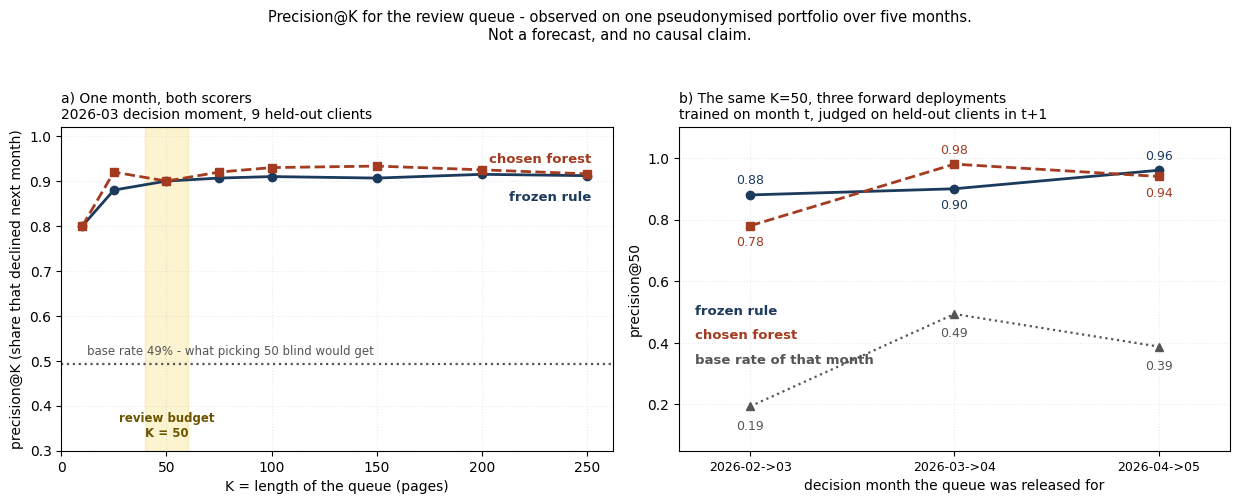


figure written to work/figures/w07_precision_at_k.png


In [13]:
K_GRID = [10, 25, 50, 75, 100, 150, 200, 250]
curve = pd.DataFrame({
    "K": K_GRID,
    "frozen rule": [precision_at_k_fair(POOL, "action_score", k=k) for k in K_GRID],
    "chosen forest": [precision_at_k_fair(POOL, "model", k=k) for k in K_GRID],
})
curve["base rate"] = POOL.label_declining.mean()
print("precision@K on the held-out clients, frozen month (tie-fair, as in w05):")
print(curve.round(3).to_string(index=False))

fwd_names = [d[0] for d in DEPLOYMENTS[1:]]
fwd_tbl = queues[queues.deployment.isin(fwd_names)]
RULE_C, MODEL_C, BASE_C = "#1b3a5c", "#a33b20", "#555555"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))

# --- panel a: the whole curve, one month, both scorers -----------------------------------------
ax1.axvspan(40, 60, color="#f0c419", alpha=0.20, zorder=0)
ax1.plot(curve.K, curve["frozen rule"], marker="o", ls="-", color=RULE_C, lw=2, zorder=3)
ax1.plot(curve.K, curve["chosen forest"], marker="s", ls="--", color=MODEL_C, lw=2, zorder=3)
ax1.axhline(curve["base rate"].iloc[0], color=BASE_C, ls=":", lw=1.6, zorder=2)
ax1.annotate("review budget\nK = 50", xy=(50, 0.355), ha="center", va="center", fontsize=8.5,
             color="#6b5300", weight="bold")
ax1.annotate(f"base rate {curve['base rate'].iloc[0]:.0%} - what picking 50 blind would get",
             xy=(12, curve["base rate"].iloc[0] + 0.02), fontsize=8.5, color=BASE_C)
ax1.annotate("frozen rule", xy=(252, curve["frozen rule"].iloc[-1] - 0.055), ha="right",
             fontsize=9.5, color=RULE_C, weight="bold")
ax1.annotate("chosen forest", xy=(252, curve["chosen forest"].iloc[-1] + 0.025), ha="right",
             fontsize=9.5, color=MODEL_C, weight="bold")
ax1.set_xlabel("K = length of the queue (pages)")
ax1.set_ylabel("precision@K (share that declined next month)")
ax1.set_title("a) One month, both scorers\n2026-03 decision moment, 9 held-out clients",
              fontsize=10, loc="left")
ax1.set_ylim(0.30, 1.02)
ax1.set_xlim(0, 262)
ax1.grid(alpha=0.25, ls=":")

# --- panel b: the same K=50, three forward deployments -----------------------------------------
x = np.arange(len(fwd_tbl))
ax2.plot(x, fwd_tbl.shipped_editor_50, marker="o", ls="-", color=RULE_C, lw=2)
ax2.plot(x, fwd_tbl.model_only_50, marker="s", ls="--", color=MODEL_C, lw=2)
ax2.plot(x, fwd_tbl.base_rate, marker="^", ls=":", color=BASE_C, lw=1.6)
for xi, (r, m, b) in enumerate(zip(fwd_tbl.shipped_editor_50, fwd_tbl.model_only_50, fwd_tbl.base_rate)):
    r_up = r >= m                       # label above whichever line is on top at this x
    ax2.annotate(f"{r:.2f}", (xi, r + (0.035 if r_up else -0.065)), ha="center", fontsize=9, color=RULE_C)
    ax2.annotate(f"{m:.2f}", (xi, m + (-0.065 if r_up else 0.035)), ha="center", fontsize=9, color=MODEL_C)
    ax2.annotate(f"{b:.2f}", (xi, b - 0.075), ha="center", fontsize=9, color=BASE_C)
for i, (txt, col) in enumerate([("frozen rule", RULE_C), ("chosen forest", MODEL_C),
                                ("base rate of that month", BASE_C)]):
    ax2.annotate(txt, xy=(0.03, 0.42 - i * 0.075), xycoords="axes fraction", fontsize=9.5,
                 color=col, weight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels([n.replace("forward ", "") for n in fwd_tbl.deployment], fontsize=9)
ax2.set_xlim(-0.35, len(fwd_tbl) - 0.65)
ax2.set_ylabel(f"precision@{TOP_K}")
ax2.set_xlabel("decision month the queue was released for")
ax2.set_title("b) The same K=50, three forward deployments\ntrained on month t, judged on held-out "
              "clients in t+1", fontsize=10, loc="left")
ax2.set_ylim(0.05, 1.10)
ax2.grid(alpha=0.25, ls=":")

fig.suptitle("Precision@K for the review queue - observed on one pseudonymised portfolio over five "
             "months.\nNot a forecast, and no causal claim.", fontsize=10.5, y=1.04)
fig.tight_layout()
fig1_path = fig_dir / "w07_precision_at_k.png"
fig.savefig(fig1_path, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nfigure written to work/figures/{fig1_path.name}")

**Figure 1 caption, as the paper will carry it.**

> Precision@K for the review queue, on 9 pseudonymised held-out clients. **(a)** The 2026-03 decision
> moment: the frozen rule and the chosen forest, tie-fair precision at K = 10…250, against the
> month's 49.4% base rate (dotted). The shaded band is where the editorial review budget lives
> (K = 50), which is the only K this lane declared in advance. **(b)** The same K = 50 across three
> time-forward deployments — trained on month *t*, judged on held-out clients in month *t+1* — with
> each month's own base rate beneath. Higher is better in both panels. Lines are distinguished by
> style and by direct labels, not by colour alone.
>
> **Supports:** the queue ranks far above its base rate at the head, in every month observed.
> **Does not support:** that either scorer beats the other (they cross, and w06's interval on the
> difference contains zero); that precision is comparable *between* panels or between months in
> panel (b), because the base rate moves under it; that any feature is a search-ranking factor; or
> that reviewing a queued page causes it to recover. Nothing here was an experiment.

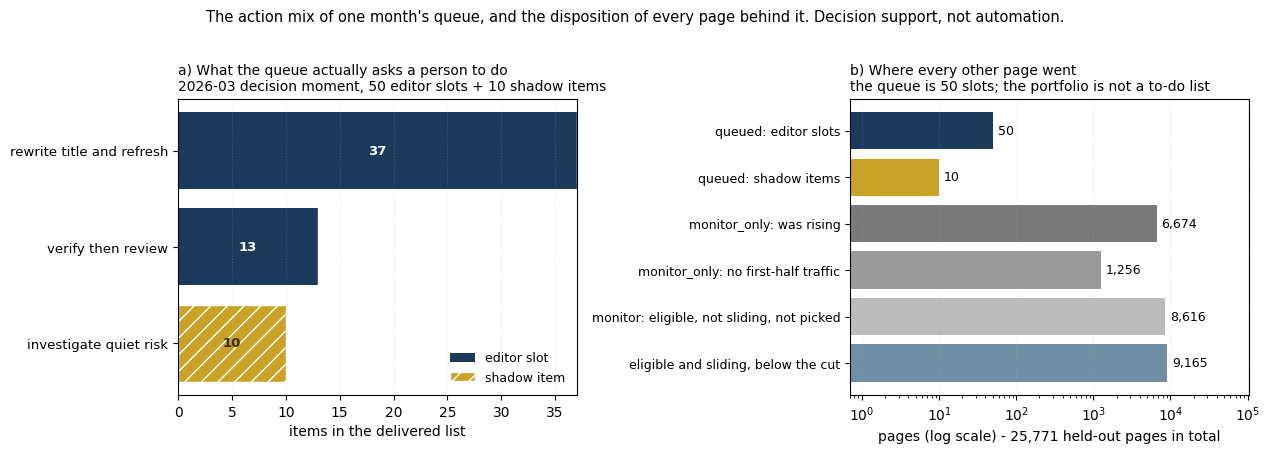

the disposition of every held-out page at the 2026-03 decision moment:
queued: editor slots                            50
queued: shadow items                            10
monitor_only: was rising                      6674
monitor_only: no first-half traffic           1256
monitor: eligible, not sliding, not picked    8616
eligible and sliding, below the cut           9165

figure written to work/figures/w07_action_mix.png


In [14]:
# --- what the queue asks for, and what the whole portfolio was sorted into ----------------------
ed = QUEUE[QUEUE.slot_type == "editor_slot"]
sh = QUEUE[QUEUE.slot_type == "shadow"]
act_ed = ed.action.value_counts()
act_sh = sh.action.value_counts()
actions_order = [a for a in ["rewrite_title_and_refresh", "refresh_now", "expand_or_consolidate",
                             "verify_then_review", "investigate_quiet_risk"]
                 if a in set(act_ed.index) | set(act_sh.index)]

disposition = pd.Series({
    "queued: editor slots": len(ed),
    "queued: shadow items": len(sh),
    "monitor_only: was rising": int(POOL.gate_riser.sum()),
    "monitor_only: no first-half traffic": int(POOL.gate_no_first_half.sum()),
    "monitor: eligible, not sliding, not picked":
        int(((POOL.eligible == 1) & (POOL.action_score == 0)).sum()) - len(sh),
    "eligible and sliding, below the cut":
        int(((POOL.eligible == 1) & (POOL.action_score > 0)).sum()) - len(ed),
})
assert disposition.sum() == len(POOL), "every page must land in exactly one disposition"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.8, 4.4))

y = np.arange(len(actions_order))
vals_ed = [int(act_ed.get(a, 0)) for a in actions_order]
vals_sh = [int(act_sh.get(a, 0)) for a in actions_order]
ax1.barh(y, vals_ed, color="#1b3a5c", label="editor slot")
ax1.barh(y, vals_sh, left=vals_ed, color="#c9a227", hatch="//", edgecolor="white", label="shadow item")
for yi, (e, s) in enumerate(zip(vals_ed, vals_sh)):
    if e:
        ax1.text(e / 2, yi, str(e), va="center", ha="center", color="white", fontsize=9.5, weight="bold")
    if s:
        ax1.text(e + s / 2, yi, str(s), va="center", ha="center", color="#3a2f00", fontsize=9.5, weight="bold")
ax1.set_yticks(y)
ax1.set_yticklabels([a.replace("_", " ") for a in actions_order], fontsize=9.5)
ax1.invert_yaxis()
ax1.set_xlabel("items in the delivered list")
ax1.set_title("a) What the queue actually asks a person to do\n2026-03 decision moment, "
              f"{len(ed)} editor slots + {len(sh)} shadow items", fontsize=10, loc="left")
ax1.legend(fontsize=9, frameon=False, loc="lower right")
ax1.grid(axis="x", alpha=0.25, ls=":")

colors = ["#1b3a5c", "#c9a227", "#7a7a7a", "#9a9a9a", "#bcbcbc", "#6f8fa6"]
yy = np.arange(len(disposition))
ax2.barh(yy, disposition.values, color=colors)
for yi, v in enumerate(disposition.values):
    ax2.text(v * 1.15, yi, f"{v:,}", va="center", fontsize=9)
ax2.set_yticks(yy)
ax2.set_yticklabels(disposition.index, fontsize=9)
ax2.invert_yaxis()
ax2.set_xscale("log")
ax2.set_xlim(0.7, len(POOL) * 4)
ax2.set_xlabel(f"pages (log scale) - {len(POOL):,} held-out pages in total")
ax2.set_title("b) Where every other page went\nthe queue is 50 slots; the portfolio is not a to-do list",
              fontsize=10, loc="left")
ax2.grid(axis="x", alpha=0.25, ls=":")

fig.suptitle("The action mix of one month's queue, and the disposition of every page behind it. "
             "Decision support, not automation.", fontsize=10.5, y=1.02)
fig.tight_layout()
fig2_path = fig_dir / "w07_action_mix.png"
fig.savefig(fig2_path, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()
print("the disposition of every held-out page at the 2026-03 decision moment:")
print(disposition.to_string())
print(f"\nfigure written to work/figures/{fig2_path.name}")

receipts["page_disposition_frozen_month"] = {k: int(v) for k, v in disposition.items()}

**Figure 2 caption, as the paper will carry it.**

> **(a)** What one month's queue actually asks a person to do: 50 editor slots and 10 shadow items at
> the 2026-03 decision moment. Two of the four rule actions — `refresh_now` and
> `expand_or_consolidate` — do not appear at all, which is the queue's own documented flaw, not an
> omission from the chart. **(b)** Where every one of the 25,771 held-out pages went, log scale.
> 7,930 pages are held at `monitor_only` by the two gates, and 17,781 are eligible but below the cut.
>
> **Supports:** the queue is 50 slots out of 25,771 pages, and most of the portfolio is deliberately
> not on it. **Does not support:** anything about outcomes — this figure is composition only.

In [15]:
# --- the queue CSV: what a person would have been handed on 2026-03-31, and nothing else --------
# No label column anywhere in this file. It is the decision-time artifact; the outcomes live in the
# receipts JSON next to it, so the deliverable can never quietly carry the answer it is judged by.
export = POOL.copy()
export["disposition"] = np.select(
    [export.gate_no_first_half == 1, export.gate_riser == 1, export.action_score > 0],
    ["monitor_only: no first-half traffic", "monitor_only: was rising", "eligible: sliding"],
    default="eligible: not sliding")
export = export.merge(QUEUE[["row_id", "slot", "slot_type", "queue", "reason_code", "action"]],
                      on="row_id", how="left")
unqueued_reason = pd.Series(
    np.where(export.gate_no_first_half == 1, "new_or_no_first_half_traffic",
    np.where(export.gate_riser == 1, "durable_riser", "holding_steady")), index=export.index)
export["reason_code"] = export.reason_code.fillna(unqueued_reason)
export["action"] = export.action.fillna(export.reason_code.map(ACTIONS))
export = export.merge(PLAYBOOK[["reason_code", "archetype", "guardrail"]], on="reason_code", how="left")
export["rule_rank"] = export.action_score.rank(ascending=False, method="first").astype(int)
export = export.sort_values(["slot", "rule_rank"], na_position="last")

QUEUE_COLS = ["slot", "slot_type", "queue", "rule_rank", "disposition", "reason_code", "archetype",
              "action", "guardrail", "action_score", "model_rank_pct", "client_hash_id",
              "content_hash_id", "imp_mar", "pos_mar", "ctr_mar", "momentum_in_month", "active_days",
              "spike_share", "gate_no_first_half", "gate_riser", "gate_verify"]
assert not any(c in QUEUE_COLS for c in ["label_declining", "imp_next", "seen_next_month"]), \
    "the delivered queue must not carry the outcome it is judged by"
csv_path = out_dir / "w07_action_queue.csv"
export[QUEUE_COLS].round(6).to_csv(csv_path, index=False)
print(f"queue written to work/outputs/{csv_path.name}: {len(export):,} rows x {len(QUEUE_COLS)} columns")
print(f"  {int(export.slot.notna().sum())} of them carry a slot ({len(ed)} editor + {len(sh)} shadow); "
      f"the rest carry a disposition and no action")
print("  regenerated on every run and gitignored by design (work/**/*.csv) - no dataset enters git")
print("\nhead of the file, ids withheld from the printout:")
print(export[QUEUE_COLS].drop(columns=["client_hash_id", "content_hash_id", "guardrail", "archetype"])
      .head(4).round(3).to_string(index=False))

# --- the result -> section map the paper will quote from ---------------------------------------
RESULT_MAP = pd.DataFrame([
    ("editor queue precision@50 = 0.90 (base rate 0.494)", "w07 s1b", "w04 + w05 receipts"),
    ("precision@50 across 3 forward deployments: 0.88 / 0.90 / 0.96", "w07 s1b", "w06 rung D"),
    ("ten in-budget trial slots cost 8.0 points of precision@50", "w07 s1c", "new this week"),
    ("trial lift over its own pool: -6 / +16 / +66 points", "w07 s1c", "w05 blind spot, re-measured"),
    ("model vs a one-line rule in the trial pool: 0.53 vs 0.43", "w07 s1e", "new this week"),
    ("no-go list with per-policy implementation status", "w07 s3", "w03 / w04 / w05"),
    ("PSI=13.1 alarm is a calendar artifact (0.08 per day)", "w07 s4", "w06 s2c"),
    ("no pre-release check would have held the failed release", "w07 s4", "w06 failed deployment"),
    ("figure: precision@K, two panels", "w07 s5", "work/figures/w07_precision_at_k.png"),
    ("figure: action mix + page disposition", "w07 s5", "work/figures/w07_action_mix.png"),
], columns=["number the paper will print", "where it is computed", "what it traces back to"])
print("\n\nRESULT -> SECTION MAP (the paper's reproducibility route starts here)")
print(RESULT_MAP.to_string(index=False))

receipts["playbook_map"] = PLAYBOOK.to_dict("records")
receipts["exports"] = {"queue_csv": f"work/outputs/{csv_path.name} (regenerated, gitignored)",
                       "figures": [f"work/figures/{fig1_path.name}", f"work/figures/{fig2_path.name}"],
                       "receipts_json": "work/outputs/w07_action_playbook_receipts.json (committed)"}
receipts["result_map"] = RESULT_MAP.to_dict("records")
receipts["environment"] = {"python": sys.version.split()[0], "numpy": np.__version__,
                           "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
                           "duckdb": duckdb.__version__, "matplotlib": matplotlib.__version__,
                           "warehouse_build": "v20260703", "seed": SEED}
receipts["verdict"] = (
    "the queue ships as 50 editor slots filled by the frozen rule plus 10 shadow items from the "
    "forest; moving ten slots to the model would have cost 8.0 points of precision@50 across three "
    "forward deployments, and the pre-registered promotion rule does not promote it on this evidence")

rec_path = out_dir / "w07_action_playbook_receipts.json"
rec_path.write_text(json.dumps(receipts, indent=2), encoding="utf-8")
print(f"\nreceipts written to work/outputs/{rec_path.name} ({len(receipts)} top-level entries)")
print(json.dumps({k: receipts[k] for k in ["queue_comparison", "trial_queue",
                                           "price_of_ten_in_budget_slots_pp", "verdict"]}, indent=2))

queue written to work/outputs/w07_action_queue.csv: 25,771 rows x 22 columns
  60 of them carry a slot (50 editor + 10 shadow); the rest carry a disposition and no action
  regenerated on every run and gitignored by design (work/**/*.csv) - no dataset enters git

head of the file, ids withheld from the printout:
 slot   slot_type  queue  rule_rank       disposition                reason_code                    action  action_score  model_rank_pct  imp_mar  pos_mar  ctr_mar  momentum_in_month  active_days  spike_share  gate_no_first_half  gate_riser  gate_verify
  1.0 editor_slot A_rule          1 eligible: sliding slipping_and_underclicking rewrite_title_and_refresh        26.219            98.9  57720.0    6.019    0.001              0.162           31        0.093                   0           0            0
  2.0 editor_slot A_rule          2 eligible: sliding      measurement_suspicion        verify_then_review        26.109            99.3   9370.0    4.334    0.000              0

**What next week's paper takes from here.**

The ranked-recommendations section writes itself from the map in 1a, the delivered list in 1d and the
CSV. The results section takes figure 1 and the receipts. The limitations section takes section 2 and
the last column of the no-go table. And the reproducibility route takes the environment block, the
seed, the warehouse build, and the result → section map printed above.

**The one-sentence version, in the words the evidence carries:**

> **Observed:** across three time-forward monthly deployments on a 27-client pseudonymised panel with
> 9 clients held out, a frozen hand-written rule filled a 50-page review queue at precision@50 of
> 0.88, 0.90 and 0.96 against base rates of 0.19, 0.49 and 0.39 (0.90 against 0.49 on w05's frozen
> grouped split, which re-measures the middle of those months). **Measured:** handing ten of those
> fifty slots to a random forest ranking inside the rule's blind spot cost 8.0 points of precision@50
> on average across the three forward deployments, while the same ten items scored −6.4, +16.5 and
> +65.6 points against their own pool's base rate. **Directional:** the model adds ranking where the
> rule is silent, and not reliably enough — on ten items over three months — to buy editorial slots
> with it. **Decision-support:** the queue is worth an editor's fifty slots a month, with a person in
> front of every item; the model rides along in shadow under a pre-registered promotion rule. **No
> causal claim** is made anywhere: nothing here was an experiment, and no page was refreshed to see
> what happened.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.